In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
matches = pd.read_csv("../data/processed/cleaned_matches.csv")

deliveries = pd.read_csv("../data/processed/cleaned_deliveries.csv")

players = pd.read_csv("../data/processed/cleaned_players.csv")

teams = pd.read_csv("../data/processed/cleaned_teams.csv")

In [3]:
matches.head()
deliveries.head()
players.head()
teams.head()

,team1
0,Pune Warriors
1,Kolkata Knight Riders
2,Rajasthan Royals
3,Kochi Tuskers Kerala
4,Gujarat Lions


Section 1: Dataset Overview


In [4]:
matches.head()
matches.tail()

deliveries.head()
deliveries.tail()

matches.shape
deliveries.shape

matches.info()
deliveries.info()

matches.describe()
deliveries.describe()

<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               756 non-null    int64
 1   season           756 non-null    str  
 2   city             756 non-null    str  
 3   date             756 non-null    str  
 4   team1            756 non-null    str  
 5   team2            756 non-null    str  
 6   toss_winner      756 non-null    str  
 7   toss_decision    756 non-null    str  
 8   result           756 non-null    str  
 9   dl_applied       756 non-null    int64
 10  winner           756 non-null    str  
 11  win_by_runs      756 non-null    int64
 12  win_by_wickets   756 non-null    int64
 13  player_of_match  756 non-null    str  
 14  venue            756 non-null    str  
 15  umpire1          754 non-null    str  
 16  umpire2          754 non-null    str  
 17  umpire3          756 non-null    str  
 18  year             756 

,match_id,inning,over,ball,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs
count,179055.000000,179055.000000,179055.000000,179055.000000,179055.000000,179055.000000,179055.000000,179055.000000,179055.000000,179055.000000,179055.000000,179055.000000,179055.000000
mean,1801.169758,1.482969,10.162916,3.615543,0.000452,0.036726,0.004937,0.021133,0.004183,0.000056,1.246913,0.067035,1.313948
std,3471.116142,0.502075,5.677628,1.806869,0.021264,0.251177,0.116487,0.194907,0.070497,0.016711,1.608322,0.342567,1.605470
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,190.000000,1.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,379.000000,1.000000,10.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,567.000000,2.000000,15.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,11415.000000,5.000000,20.000000,9.000000,1.000000,5.000000,4.000000,5.000000,5.000000,5.000000,7.000000,7.000000,10.000000


# Section 2: Match Analysis

## 2.1 Total IPL Matches Played

### Business Question

How many IPL matches are available in the dataset?

### Objective

Determine the total number of matches available for analysis.

In [5]:
total_matches = matches.shape[0]

print("Total IPL Matches :", total_matches)

Total IPL Matches : 756


### Business Insight

- The dataset contains **756 IPL matches**.
- This provides a large historical dataset suitable for identifying long-term trends in team and player performance.

## 2.2 Number of IPL Seasons

### Business Question

How many IPL seasons are included in the dataset?

### Objective

Identify the total number of seasons available for analysis.

In [6]:
total_seasons = matches["season"].nunique()

print("Total Seasons :", total_seasons)

Total Seasons : 12


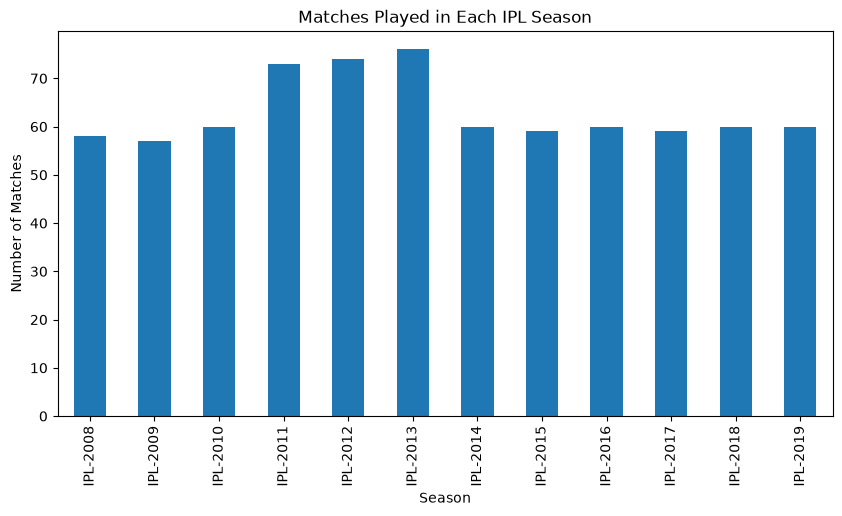

In [7]:
season_counts = matches["season"].value_counts().sort_index()

plt.figure(figsize=(10,5))

season_counts.plot(kind="bar")

plt.title("Matches Played in Each IPL Season")

plt.xlabel("Season")

plt.ylabel("Number of Matches")

plt.show()

### Business Insight

- The dataset contains matches from multiple IPL seasons.
- Some seasons have more matches due to tournament expansion and additional teams.

## 2.3 Matches Played Every Season

### Business Question

How many matches were played in each IPL season?

### Objective

Compare tournament size across different seasons.

In [23]:
matches_df = matches
deliveries_df = deliveries

In [26]:
season_matches = matches["season"].value_counts().sort_index()

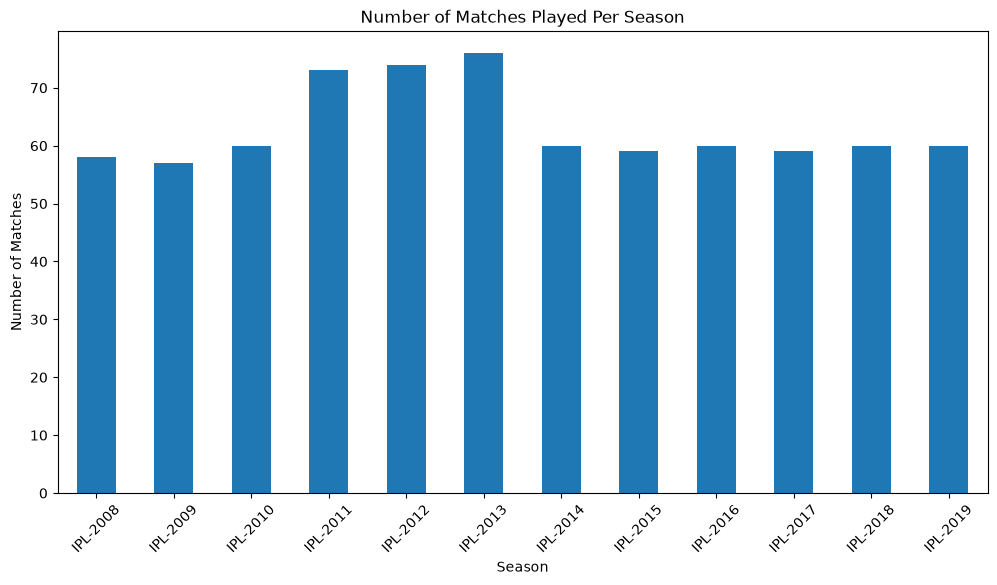

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

season_matches.plot(kind="bar")

plt.title("Number of Matches Played Per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)

plt.show()

### Business Insight

- The number of matches varies by season.
- Growth in the tournament format resulted in more matches during certain years.

## 2.4 Matches Played in Each City

### Business Question

Which cities have hosted the most IPL matches?

### Objective

Identify the most frequently used IPL venues by city.

In [28]:
city_matches = matches["city"].value_counts()

city_matches

city
Mumbai            101
Kolkata            77
Delhi              74
Bangalore          66
Hyderabad          64
Chennai            57
Jaipur             47
Chandigarh         46
Pune               38
Durban             15
Bengaluru          14
Visakhapatnam      13
Centurion          12
Ahmedabad          12
Rajkot             10
Mohali             10
Indore              9
Dharamsala          9
Johannesburg        8
Cape Town           7
Port Elizabeth      7
Cuttack             7
Ranchi              7
Abu Dhabi           7
Unknown             7
Raipur              6
Sharjah             6
Kochi               5
Kanpur              4
East London         3
Kimberley           3
Nagpur              3
Bloemfontein        2
Name: count, dtype: int64

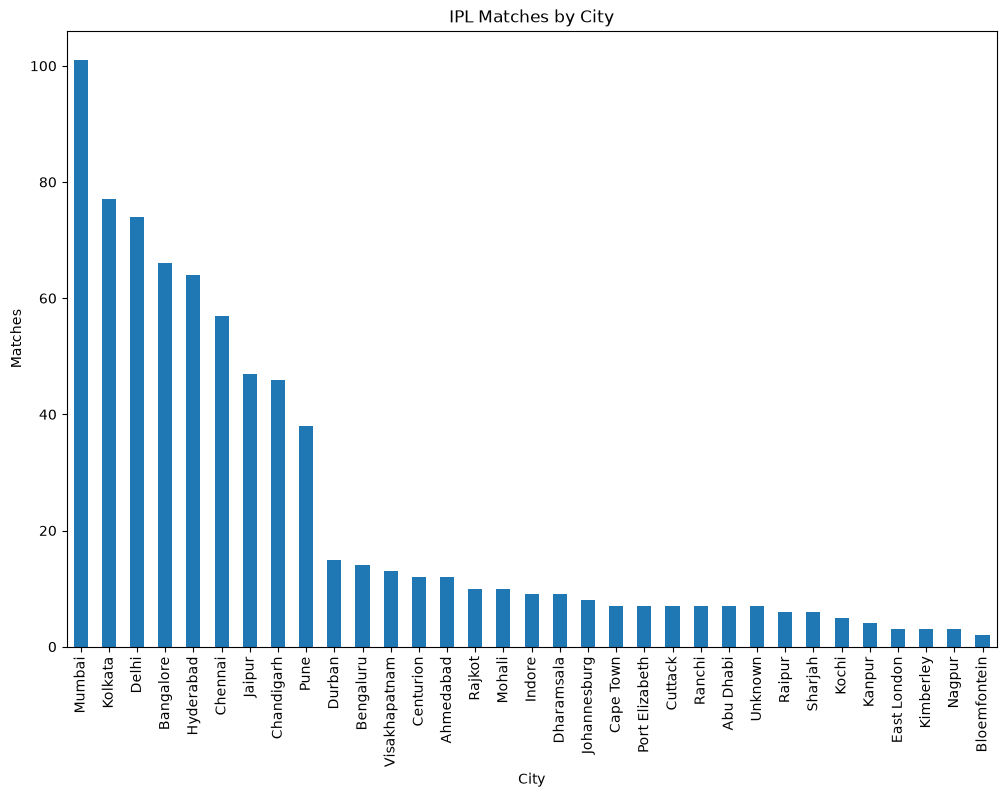

In [29]:
plt.figure(figsize=(12,8))

city_matches.plot(kind="bar")

plt.title("IPL Matches by City")

plt.xlabel("City")

plt.ylabel("Matches")

plt.xticks(rotation=90)

plt.show()

### Business Insight

- A few cities host a large proportion of IPL matches.
- These cities serve as major IPL venues and frequently host league-stage and playoff matches.

## 2.5 Top 10 IPL Venues

### Business Question

Which stadiums have hosted the highest number of IPL matches?

### Objective

Identify the most frequently used IPL venues.

In [30]:
venue_matches = matches["venue"].value_counts().head(10)

venue_matches

venue
Eden Gardens                                  77
M Chinnaswamy Stadium                         73
Wankhede Stadium                              73
Feroz Shah Kotla                              67
Rajiv Gandhi International Stadium, Uppal     56
MA Chidambaram Stadium, Chepauk               49
Sawai Mansingh Stadium                        47
Punjab Cricket Association Stadium, Mohali    35
Maharashtra Cricket Association Stadium       21
Dr DY Patil Sports Academy                    17
Name: count, dtype: int64

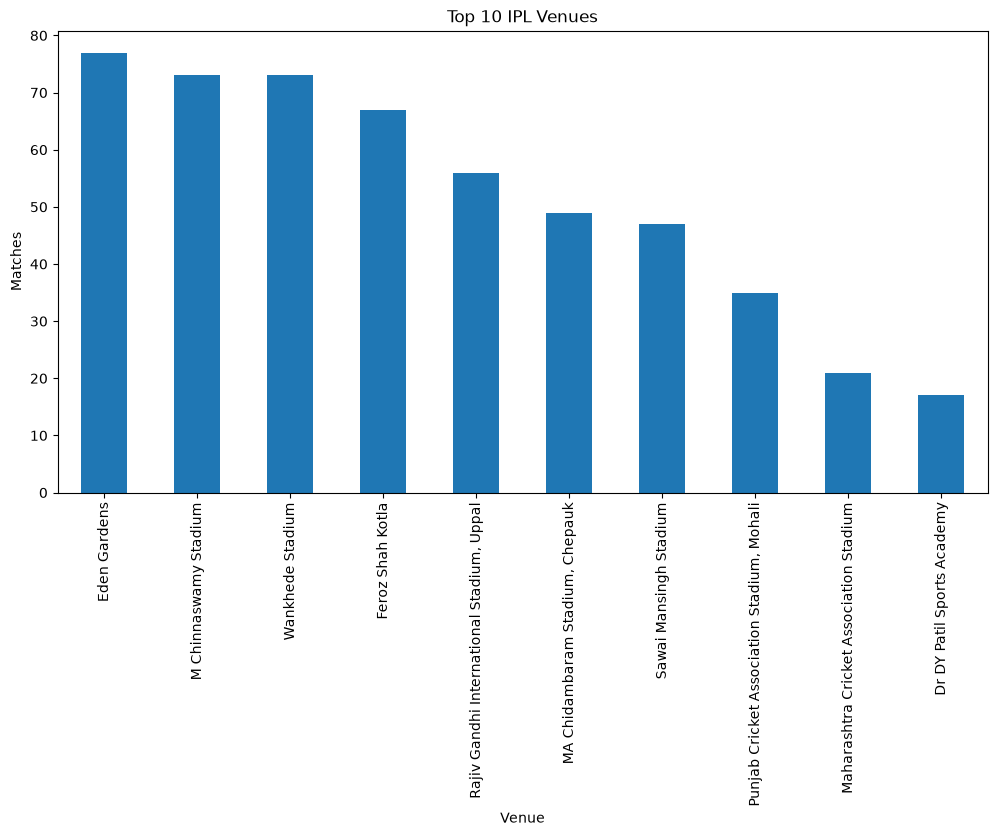

In [31]:
plt.figure(figsize=(12,6))

venue_matches.plot(kind="bar")

plt.title("Top 10 IPL Venues")

plt.xlabel("Venue")

plt.ylabel("Matches")

plt.xticks(rotation=90)

plt.show()

### Business Insight

- Certain stadiums host significantly more IPL matches than others.
- These venues are often selected because of higher seating capacity, infrastructure, or historical importance.

## 2.6 Toss Winner Analysis

### Business Question

Which IPL teams have won the toss most frequently?

### Objective

Analyze toss-winning frequency to identify teams that have won the toss most often across all IPL seasons.

In [32]:
toss_winner = matches["toss_winner"].value_counts()

toss_winner

toss_winner
Mumbai Indians                 98
Kolkata Knight Riders          92
Delhi Capitals                 90
Chennai Super Kings            89
Royal Challengers Bangalore    81
Kings XI Punjab                81
Rajasthan Royals               80
Sunrisers Hyderabad            46
Deccan Chargers                43
Pune Warriors                  20
Gujarat Lions                  15
Rising Pune Supergiants        13
Kochi Tuskers Kerala            8
Name: count, dtype: int64

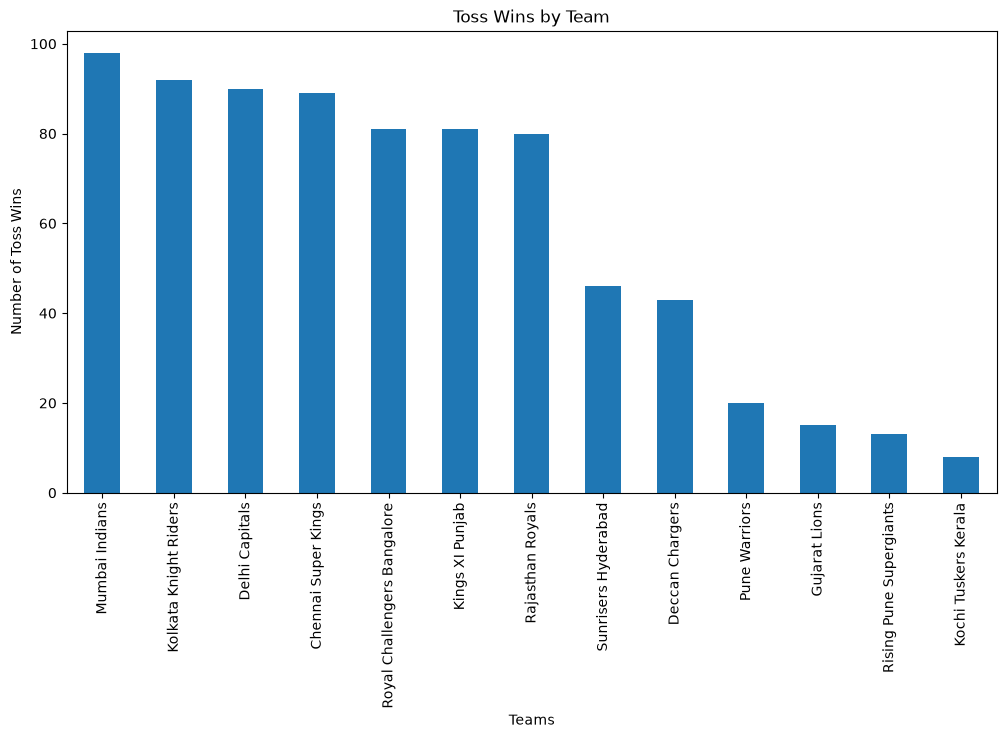

In [33]:
plt.figure(figsize=(12,6))

toss_winner.plot(kind="bar")

plt.title("Toss Wins by Team")

plt.xlabel("Teams")

plt.ylabel("Number of Toss Wins")

plt.xticks(rotation=90)

plt.show()

### Business Insight

- Some teams have won the toss considerably more often than others.
- However, winning the toss does not necessarily guarantee winning the match.

## 2.7 Toss Decision Analysis

### Business Question

After winning the toss, do teams prefer to bat first or field first?

### Objective

Understand the decision-making strategy after winning the toss.

In [34]:
toss_decision = matches["toss_decision"].value_counts()

toss_decision

toss_decision
field    463
bat      293
Name: count, dtype: int64

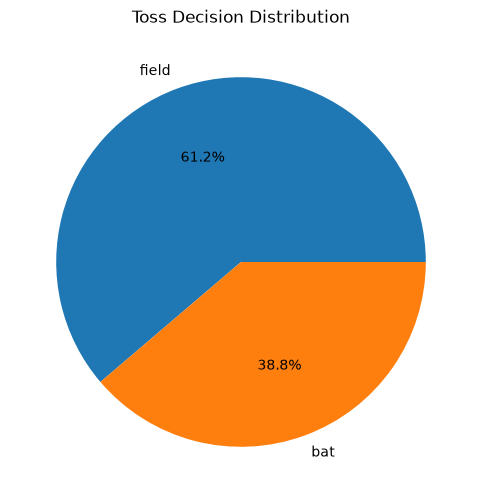

In [35]:
plt.figure(figsize=(6,6))

toss_decision.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Toss Decision Distribution")

plt.show()

### Business Insight

- Teams often choose to field first, particularly in conditions where chasing is considered advantageous.
- Toss strategy may vary depending on venue, weather, and match conditions.

## 2.8 Match Winner Analysis

### Business Question

Which IPL team has won the highest number of matches?

### Objective

Identify the most successful IPL teams based on total wins.

In [36]:
winner = matches["winner"].value_counts()

winner

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Delhi Capitals                  77
Rajasthan Royals                75
Sunrisers Hyderabad             58
Deccan Chargers                 29
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
No Result                        4
Name: count, dtype: int64

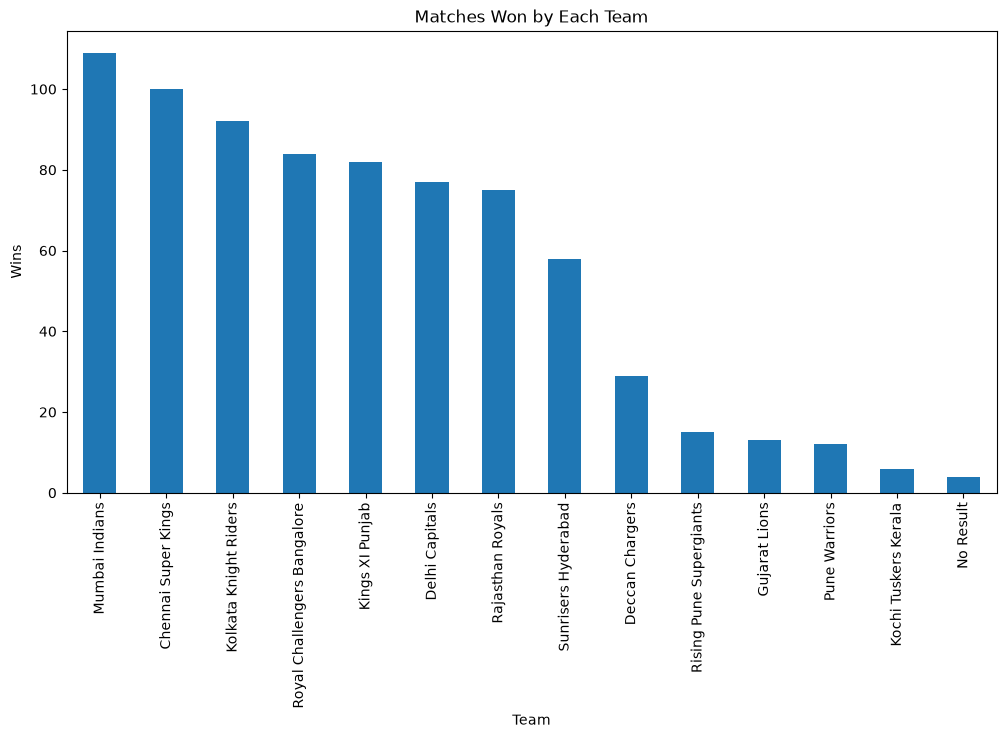

In [37]:
plt.figure(figsize=(12,6))

winner.plot(kind="bar")

plt.title("Matches Won by Each Team")

plt.xlabel("Team")

plt.ylabel("Wins")

plt.xticks(rotation=90)

plt.show()

### Business Insight

- Teams with the highest number of wins have demonstrated consistent performance across multiple IPL seasons.
- Historical success often reflects strong team management and player performance.

## 2.9 Largest Victory by Runs

### Business Question

Which match had the highest winning margin by runs?

### Objective

Identify the most dominant batting victory in IPL history.

In [40]:
largest_runs = matches.loc[matches["win_by_runs"].idxmax()]

largest_runs

id                               44
season                     IPL-2017
city                          Delhi
date                     2017-05-06
team1                Mumbai Indians
team2                Delhi Capitals
toss_winner          Delhi Capitals
toss_decision                 field
result                       normal
dl_applied                        0
winner               Mumbai Indians
win_by_runs                     146
win_by_wickets                    0
player_of_match         LMP Simmons
venue              Feroz Shah Kotla
umpire1                 Nitin Menon
umpire2                   CK Nandan
umpire3               Not Available
year                           2017
month                             5
day                               6
Name: 43, dtype: object

### Business Insight

- This match recorded the highest victory margin by runs, highlighting one of the most dominant batting performances in the dataset.

## 2.10 Largest Victory by Wickets

### Business Question

Which match had the highest winning margin by wickets?

### Objective

Identify the most dominant run chase in IPL history.

In [41]:
largest_wickets = matches.loc[matches["win_by_wickets"].idxmax()]

largest_wickets

id                                                      3
season                                           IPL-2017
city                                               Rajkot
date                                           2017-04-07
team1                                       Gujarat Lions
team2                               Kolkata Knight Riders
toss_winner                         Kolkata Knight Riders
toss_decision                                       field
result                                             normal
dl_applied                                              0
winner                              Kolkata Knight Riders
win_by_runs                                             0
win_by_wickets                                         10
player_of_match                                   CA Lynn
venue              Saurashtra Cricket Association Stadium
umpire1                                       Nitin Menon
umpire2                                         CK Nandan
umpire3       

### Business Insight

- Winning by the maximum number of wickets indicates an exceptionally successful chase with minimal wickets lost.

## 2.11 Player of the Match Awards

### Business Question

Which players have won the most Player of the Match awards?

### Objective

Identify the players who consistently delivered match-winning performances.

In [42]:
pom = matches["player_of_match"].value_counts().head(10)

pom

player_of_match
CH Gayle          21
AB de Villiers    20
MS Dhoni          17
DA Warner         17
RG Sharma         17
YK Pathan         16
SR Watson         15
SK Raina          14
G Gambhir         13
MEK Hussey        12
Name: count, dtype: int64

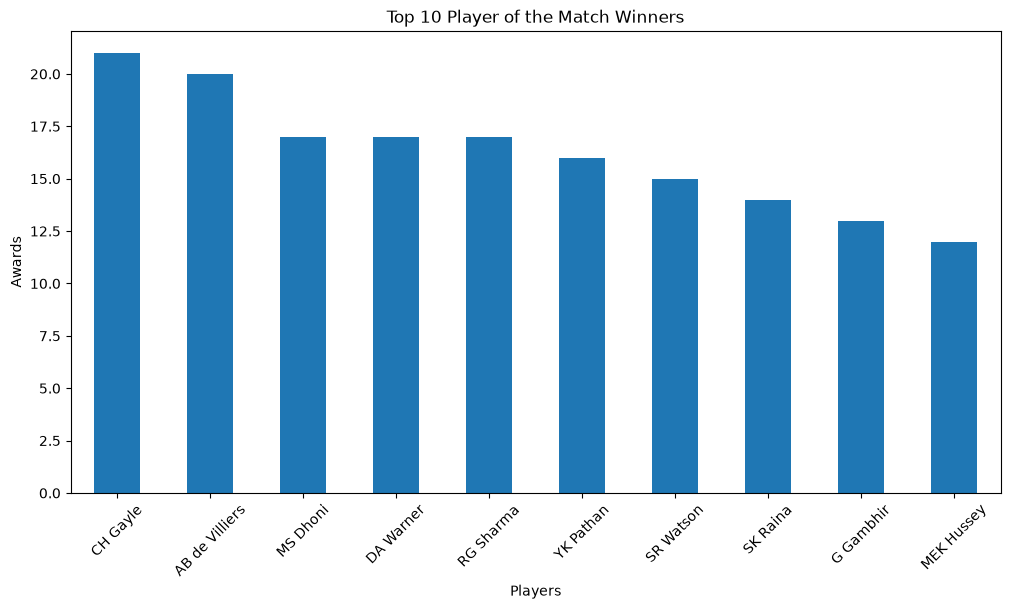

In [43]:
plt.figure(figsize=(12,6))

pom.plot(kind="bar")

plt.title("Top 10 Player of the Match Winners")

plt.xlabel("Players")

plt.ylabel("Awards")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- Frequent Player of the Match awards indicate players who consistently influenced match outcomes.
- These players often served as key performers for their teams across multiple seasons.

# Section 3: Team Performance Analysis

## 3.1 Team Winning Percentage

### Business Question

Which IPL teams have the highest winning percentage?

### Objective

Calculate the winning percentage of each team based on total matches played and total matches won.

In [44]:
team1 = matches["team1"].value_counts()
team2 = matches["team2"].value_counts()

matches_played = team1.add(team2, fill_value=0)

matches_played

team1
Chennai Super Kings            164
Deccan Chargers                 75
Delhi Capitals                 177
Gujarat Lions                   30
Kings XI Punjab                176
Kochi Tuskers Kerala            14
Kolkata Knight Riders          178
Mumbai Indians                 187
Pune Warriors                   46
Rajasthan Royals               147
Rising Pune Supergiants         30
Royal Challengers Bangalore    180
Sunrisers Hyderabad            108
Name: count, dtype: int64

In [45]:
matches_won = matches["winner"].value_counts()

matches_won

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Delhi Capitals                  77
Rajasthan Royals                75
Sunrisers Hyderabad             58
Deccan Chargers                 29
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
No Result                        4
Name: count, dtype: int64

In [46]:
team_performance = pd.DataFrame({
    "Matches Played": matches_played,
    "Matches Won": matches_won
})

team_performance = team_performance.fillna(0)

team_performance

,Matches Played,Matches Won
Chennai Super Kings,164.0,100
Deccan Chargers,75.0,29
Delhi Capitals,177.0,77
Gujarat Lions,30.0,13
Kings XI Punjab,176.0,82
Kochi Tuskers Kerala,14.0,6
Kolkata Knight Riders,178.0,92
Mumbai Indians,187.0,109
No Result,0.0,4
Pune Warriors,46.0,12


In [47]:
team_performance["Winning Percentage"] = (
    team_performance["Matches Won"] /
    team_performance["Matches Played"]
) * 100

team_performance

,Matches Played,Matches Won,Winning Percentage
Chennai Super Kings,164.0,100,60.975610
Deccan Chargers,75.0,29,38.666667
Delhi Capitals,177.0,77,43.502825
Gujarat Lions,30.0,13,43.333333
Kings XI Punjab,176.0,82,46.590909
Kochi Tuskers Kerala,14.0,6,42.857143
Kolkata Knight Riders,178.0,92,51.685393
Mumbai Indians,187.0,109,58.288770
No Result,0.0,4,inf
Pune Warriors,46.0,12,26.086957


In [48]:
team_performance = team_performance.sort_values(
    by="Winning Percentage",
    ascending=False
)

team_performance

,Matches Played,Matches Won,Winning Percentage
No Result,0.0,4,inf
Chennai Super Kings,164.0,100,60.975610
Mumbai Indians,187.0,109,58.288770
Sunrisers Hyderabad,108.0,58,53.703704
Kolkata Knight Riders,178.0,92,51.685393
Rajasthan Royals,147.0,75,51.020408
Rising Pune Supergiants,30.0,15,50.000000
Royal Challengers Bangalore,180.0,84,46.666667
Kings XI Punjab,176.0,82,46.590909
Delhi Capitals,177.0,77,43.502825


d:\projects\ipl cricket analysis\venv\Lib\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
d:\projects\ipl cricket analysis\venv\Lib\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


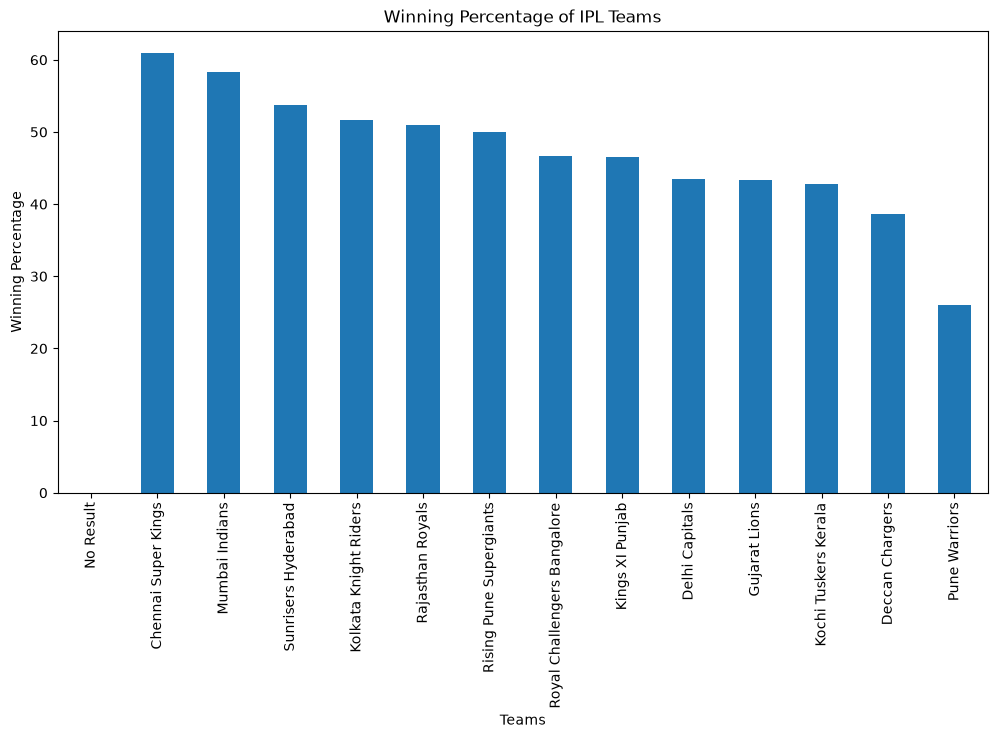

In [49]:
plt.figure(figsize=(12,6))

team_performance["Winning Percentage"].plot(kind="bar")

plt.title("Winning Percentage of IPL Teams")

plt.xlabel("Teams")

plt.ylabel("Winning Percentage")

plt.xticks(rotation=90)

plt.show()

### Business Insight

- Teams with higher winning percentages have consistently performed well across multiple IPL seasons.
- Winning percentage is a better performance indicator than total wins because it accounts for the number of matches played.

## 3.2 Toss Win vs Match Win

### Business Question

Does winning the toss increase the likelihood of winning the match?

### Objective

Compare toss winners with match winners.

In [50]:
toss_match_win = matches[
    matches["toss_winner"] == matches["winner"]
]

toss_match_win.shape[0]

393

In [51]:
percentage = (
    toss_match_win.shape[0] /
    matches.shape[0]
) * 100

print("Percentage :", round(percentage,2),"%")

Percentage : 51.98 %


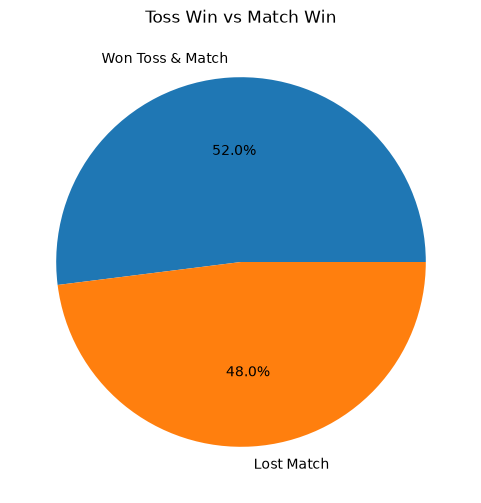

In [52]:
labels = ["Won Toss & Match","Lost Match"]

values = [
    toss_match_win.shape[0],
    matches.shape[0]-toss_match_win.shape[0]
]

plt.figure(figsize=(6,6))

plt.pie(values,
        labels=labels,
        autopct="%1.1f%%")

plt.title("Toss Win vs Match Win")

plt.show()

### Business Insight

- Winning the toss improves the chances of winning the match but does not guarantee success.
- Team performance remains the primary factor influencing match outcomes.

## 3.3 Bat First vs Chasing

### Business Question

Which strategy is more successful?

### Objective

Compare the number of matches won while batting first versus chasing.

In [53]:
bat_first = matches[matches["win_by_runs"] > 0].shape[0]

chasing = matches[matches["win_by_wickets"] > 0].shape[0]

print("Bat First Wins :", bat_first)

print("Chasing Wins :", chasing)

Bat First Wins : 337
Chasing Wins : 406


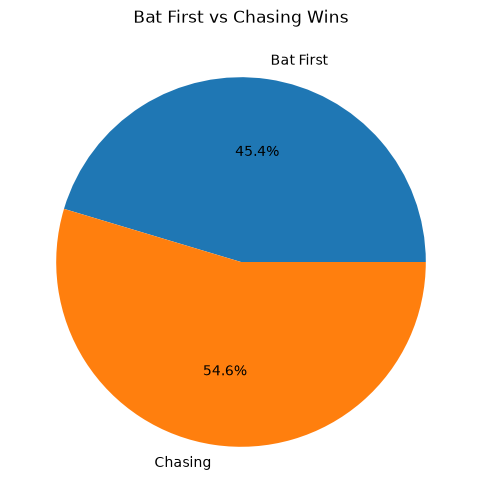

In [54]:
plt.figure(figsize=(6,6))

plt.pie(
    [bat_first,chasing],
    labels=["Bat First","Chasing"],
    autopct="%1.1f%%"
)

plt.title("Bat First vs Chasing Wins")

plt.show()

### Business Insight

- Comparing batting-first victories with successful chases helps evaluate the impact of match strategy.
- Teams may prefer different strategies depending on venue and pitch conditions.

## 3.4 Best Chasing Team

### Business Question

Which team has won the most matches while chasing?

### Objective

Identify teams that perform best when batting second.

In [55]:
chasing_wins = matches[
    matches["win_by_wickets"] > 0
]["winner"].value_counts()

chasing_wins

winner
Kolkata Knight Riders          56
Mumbai Indians                 50
Delhi Capitals                 48
Royal Challengers Bangalore    48
Chennai Super Kings            48
Rajasthan Royals               46
Kings XI Punjab                42
Sunrisers Hyderabad            27
Gujarat Lions                  12
Deccan Chargers                11
Rising Pune Supergiants         8
Pune Warriors                   6
Kochi Tuskers Kerala            4
Name: count, dtype: int64

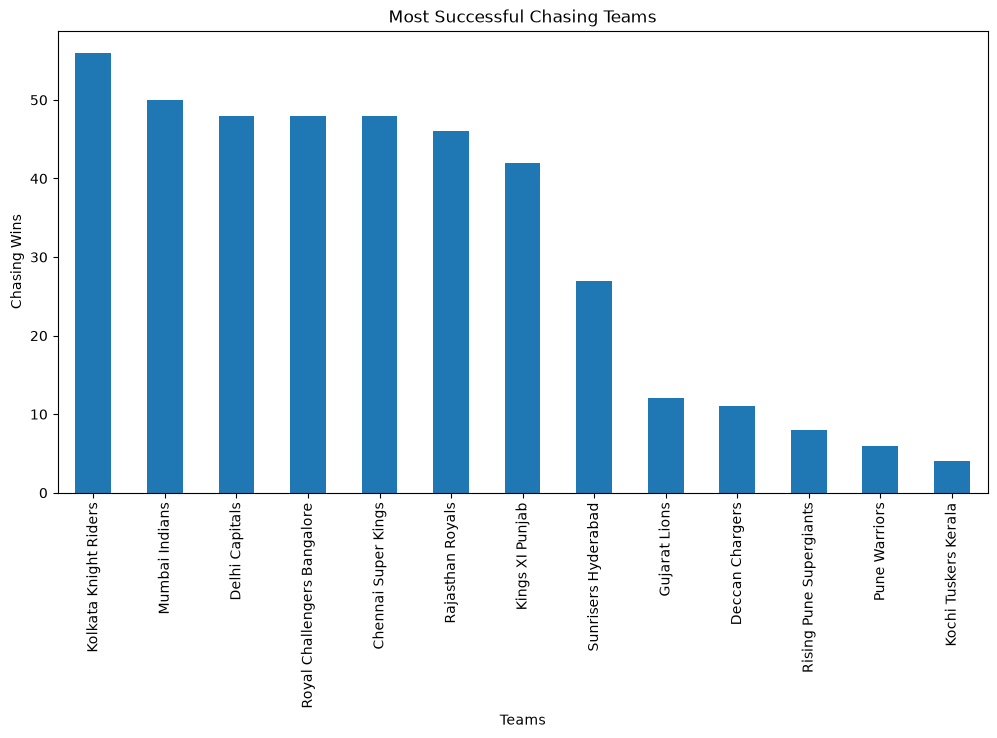

In [56]:
plt.figure(figsize=(12,6))

chasing_wins.plot(kind="bar")

plt.title("Most Successful Chasing Teams")

plt.xlabel("Teams")

plt.ylabel("Chasing Wins")

plt.xticks(rotation=90)

plt.show()

### Business Insight

- Some teams consistently perform well under the pressure of chasing targets.
- Strong finishers and adaptable batting lineups contribute to successful run chases.

## 3.5 Best Batting First Team

### Business Question

Which team has won the most matches after batting first?

### Objective

Identify teams that successfully defend totals.

In [57]:
bat_first_wins = matches[
    matches["win_by_runs"] > 0
]["winner"].value_counts()

bat_first_wins

winner
Mumbai Indians                 57
Chennai Super Kings            52
Kings XI Punjab                38
Kolkata Knight Riders          36
Royal Challengers Bangalore    35
Sunrisers Hyderabad            30
Delhi Capitals                 28
Rajasthan Royals               27
Deccan Chargers                18
Rising Pune Supergiants         7
Pune Warriors                   6
Kochi Tuskers Kerala            2
Gujarat Lions                   1
Name: count, dtype: int64

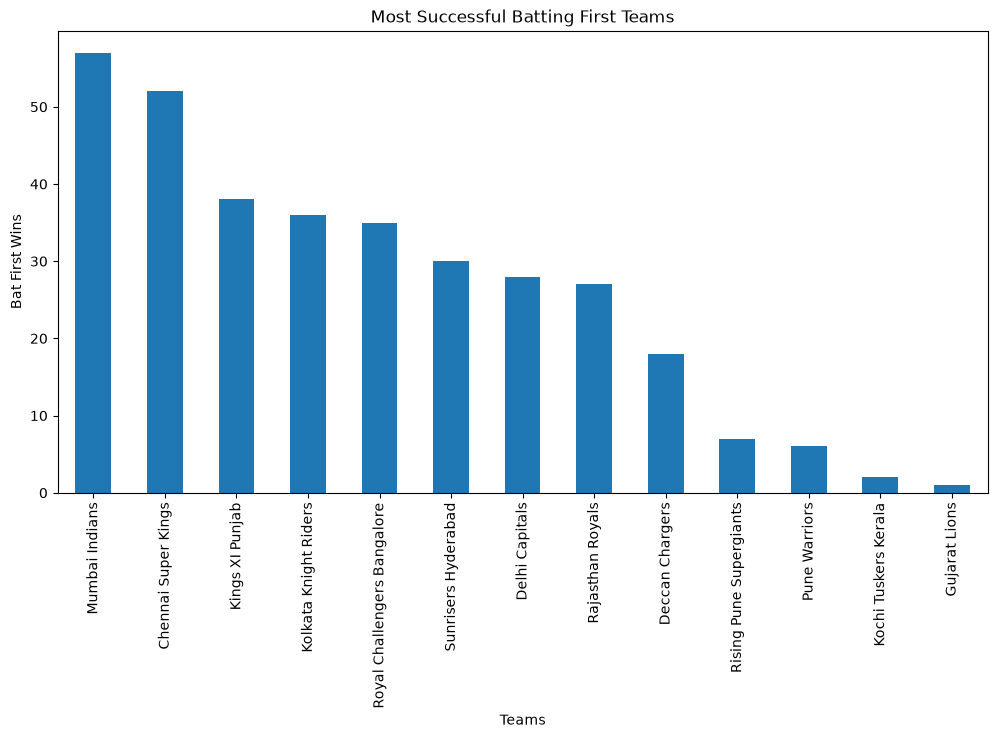

In [58]:
plt.figure(figsize=(12,6))

bat_first_wins.plot(kind="bar")

plt.title("Most Successful Batting First Teams")

plt.xlabel("Teams")

plt.ylabel("Bat First Wins")

plt.xticks(rotation=90)

plt.show()

### Business Insight

- Successful defending teams generally possess strong bowling attacks capable of controlling run chases.

## 3.6 Most Consistent Teams

### Business Question

Which teams have consistently performed well across IPL seasons?

### Objective

Rank teams based on winning percentage.

In [59]:
team_performance.sort_values(
    by="Winning Percentage",
    ascending=False
).head(10)

,Matches Played,Matches Won,Winning Percentage
No Result,0.0,4,inf
Chennai Super Kings,164.0,100,60.975610
Mumbai Indians,187.0,109,58.288770
Sunrisers Hyderabad,108.0,58,53.703704
Kolkata Knight Riders,178.0,92,51.685393
Rajasthan Royals,147.0,75,51.020408
Rising Pune Supergiants,30.0,15,50.000000
Royal Challengers Bangalore,180.0,84,46.666667
Kings XI Punjab,176.0,82,46.590909
Delhi Capitals,177.0,77,43.502825


d:\projects\ipl cricket analysis\venv\Lib\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
d:\projects\ipl cricket analysis\venv\Lib\site-packages\matplotlib\transforms.py:2496: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


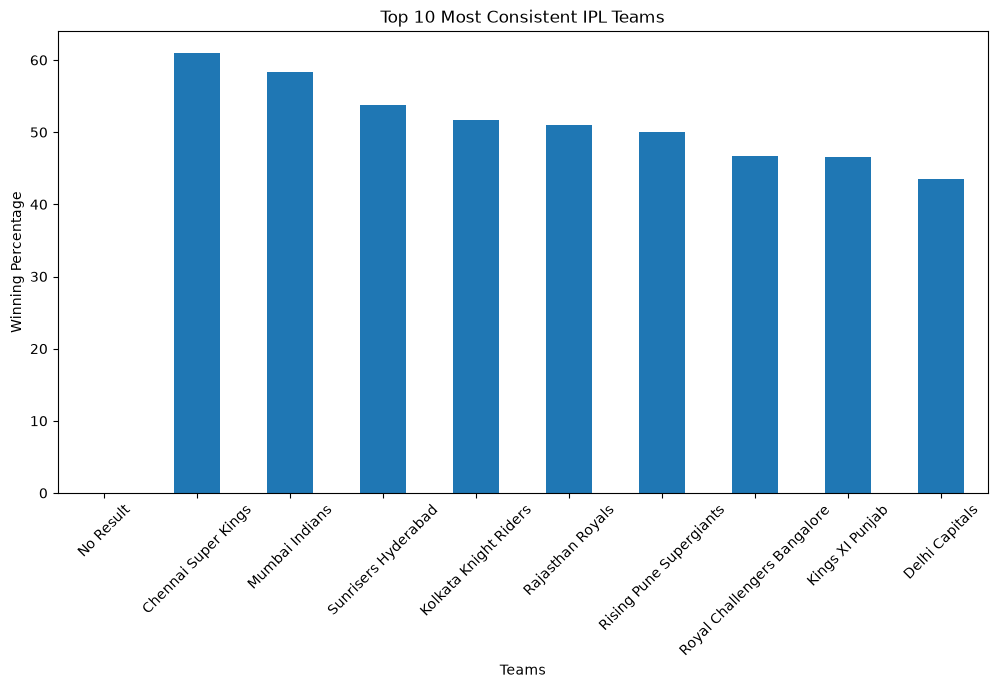

In [60]:
plt.figure(figsize=(12,6))

team_performance.head(10)["Winning Percentage"].plot(
    kind="bar"
)

plt.title("Top 10 Most Consistent IPL Teams")

plt.xlabel("Teams")

plt.ylabel("Winning Percentage")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- Winning percentage provides a balanced measure of consistency by considering both victories and total matches played.
- Teams with high winning percentages have maintained strong performance over multiple seasons.

In [61]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')

In [62]:
list(deliveries.columns)

['match_id',
 'inning',
 'batting_team',
 'bowling_team',
 'over',
 'ball',
 'batsman',
 'non_striker',
 'bowler',
 'is_super_over',
 'wide_runs',
 'bye_runs',
 'legbye_runs',
 'noball_runs',
 'penalty_runs',
 'batsman_runs',
 'extra_runs',
 'total_runs',
 'player_dismissed',
 'dismissal_kind',
 'fielder']

# Section 4: Player Performance Analysis

## 4.1 Top 10 Run Scorers

### Business Question

Which batsmen have scored the highest number of runs in IPL history?

### Objective

Calculate the total runs scored by each batsman and identify the top 10 run scorers.

In [63]:
top_runs = (
    deliveries
    .groupby("batsman")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
)

top_runs.head(10)

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4631
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4444
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64

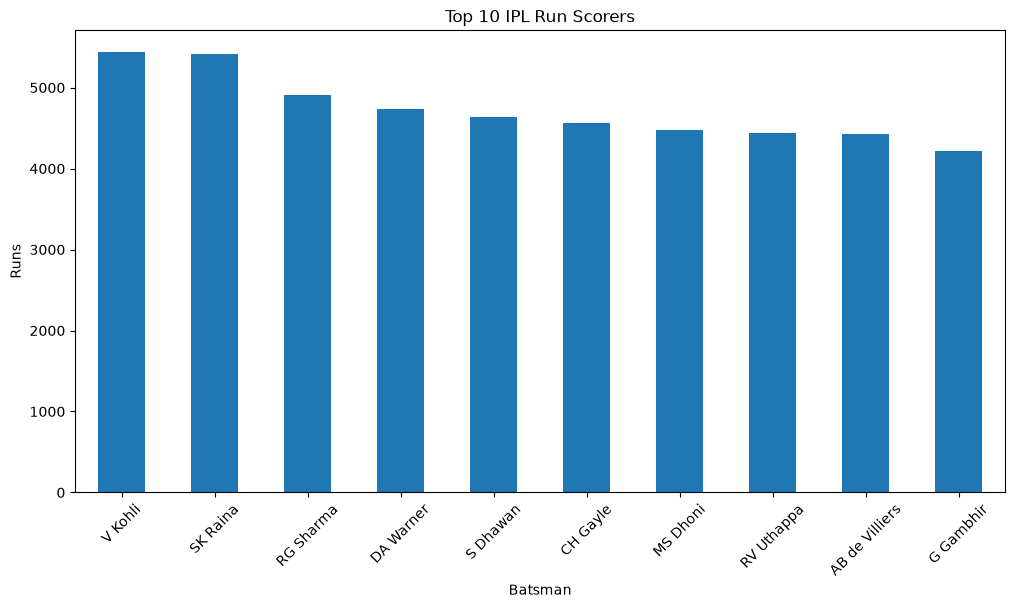

In [64]:
plt.figure(figsize=(12,6))

top_runs.head(10).plot(kind="bar")

plt.title("Top 10 IPL Run Scorers")

plt.xlabel("Batsman")

plt.ylabel("Runs")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- The top run scorers have consistently performed across multiple IPL seasons.
- These players are valuable because of their long-term batting contribution.

## 4.2 Players with the Most Fours

### Business Question

Which batsmen have hit the highest number of fours?

### Objective

Count the number of boundaries (4 runs) scored by each batsman.

In [65]:
fours = deliveries[deliveries["batsman_runs"] == 4]

top_fours = (
    fours.groupby("batsman")
    .size()
    .sort_values(ascending=False)
)

top_fours.head(10)

batsman
S Dhawan      526
SK Raina      495
G Gambhir     492
V Kohli       482
DA Warner     459
RV Uthappa    436
RG Sharma     431
AM Rahane     404
CH Gayle      376
PA Patel      366
dtype: int64

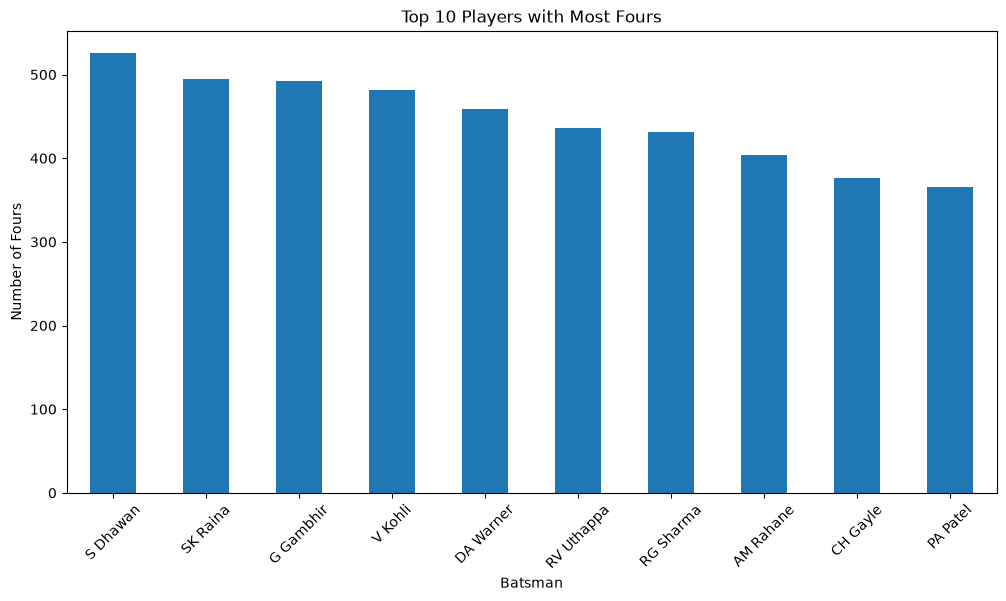

In [66]:
plt.figure(figsize=(12,6))

top_fours.head(10).plot(kind="bar")

plt.title("Top 10 Players with Most Fours")

plt.xlabel("Batsman")

plt.ylabel("Number of Fours")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- Players with the highest number of fours are generally consistent stroke-makers.
- Boundary scoring is an important indicator of batting effectiveness.

## 4.3 Players with the Most Sixes

### Business Question

Which batsmen have hit the highest number of sixes?

### Objective

Identify the most aggressive batsmen based on sixes scored.

In [67]:
sixes = deliveries[deliveries["batsman_runs"] == 6]

top_sixes = (
    sixes.groupby("batsman")
    .size()
    .sort_values(ascending=False)
)

top_sixes.head(10)

batsman
CH Gayle          327
AB de Villiers    214
MS Dhoni          207
SK Raina          195
RG Sharma         194
V Kohli           191
DA Warner         181
SR Watson         177
KA Pollard        175
YK Pathan         161
dtype: int64

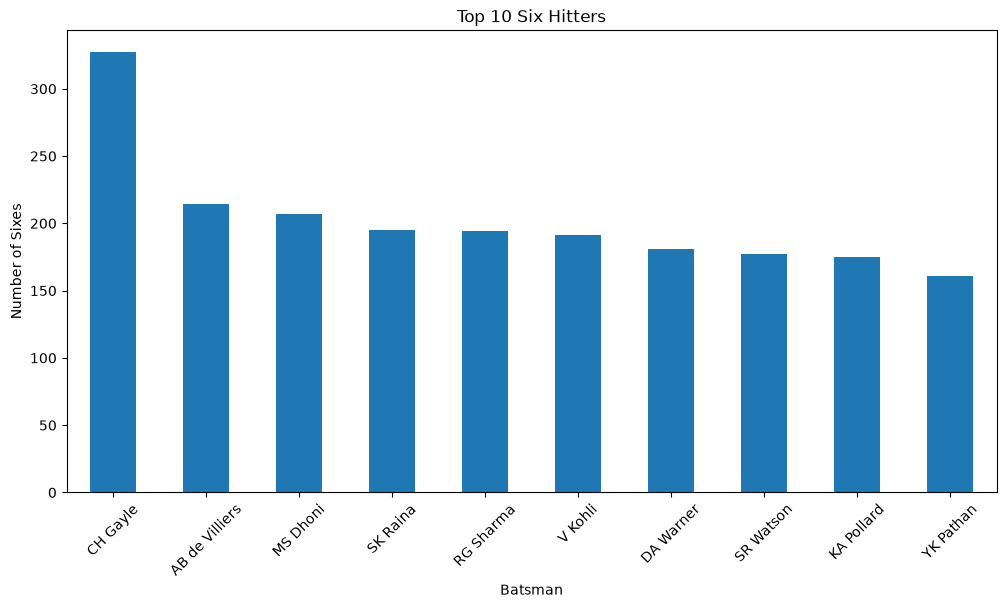

In [68]:
plt.figure(figsize=(12,6))

top_sixes.head(10).plot(kind="bar")

plt.title("Top 10 Six Hitters")

plt.xlabel("Batsman")

plt.ylabel("Number of Sixes")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- Six-hitting ability reflects a player's power-hitting capability.
- These players often accelerate scoring during the middle and death overs.

## 4.4 Highest Strike Rate

### Business Question

Which batsmen have the highest strike rate?

### Objective

Calculate strike rates for batsmen who have faced at least 500 balls to ensure a fair comparison.

In [69]:
runs = deliveries.groupby("batsman")["batsman_runs"].sum()

balls = deliveries.groupby("batsman").size()

strike_rate = pd.DataFrame({
    "Runs": runs,
    "Balls": balls
})

strike_rate["Strike Rate"] = (
    strike_rate["Runs"] /
    strike_rate["Balls"]
) * 100

strike_rate = strike_rate[strike_rate["Balls"] >= 500]

strike_rate.sort_values(
    by="Strike Rate",
    ascending=False
).head(10)

,Runs,Balls,Strike Rate
batsman,,,
AD Russell,1444,802,180.049875
RR Pant,1792,1104,162.318841
GJ Maxwell,1403,902,155.543237
HH Pandya,1118,736,151.902174
JC Buttler,1431,953,150.157398
V Sehwag,2728,1833,148.827059
AB de Villiers,4428,2976,148.790323
CH Gayle,4560,3131,145.640370
KH Pandya,915,635,144.094488


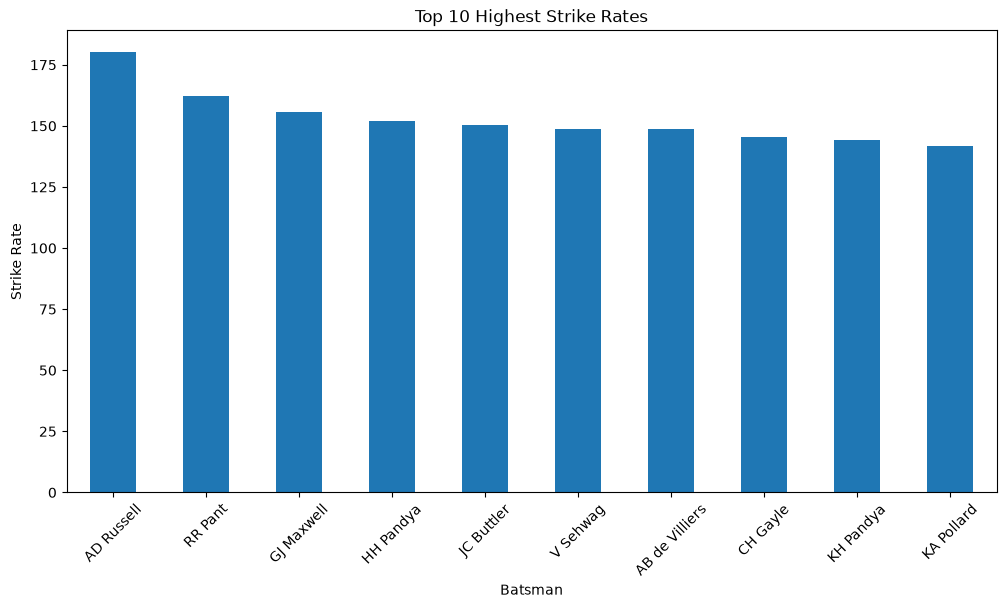

In [70]:
plt.figure(figsize=(12,6))

strike_rate.sort_values(
    by="Strike Rate",
    ascending=False
).head(10)["Strike Rate"].plot(kind="bar")

plt.title("Top 10 Highest Strike Rates")

plt.xlabel("Batsman")

plt.ylabel("Strike Rate")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- Strike rate measures scoring speed.
- Applying a minimum balls-faced threshold ensures meaningful comparisons between players.

## 4.5 Top 10 Wicket Takers

### Business Question

Which bowlers have taken the most wickets?

### Objective

Identify the most successful wicket-taking bowlers in IPL history.

In [71]:
wickets = deliveries[
    deliveries["player_dismissed"].notna()
]

top_wickets = (
    wickets.groupby("bowler")
    .size()
    .sort_values(ascending=False)
)

top_wickets.head(10)

bowler
SL Malinga         188
DJ Bravo           168
A Mishra           165
Harbhajan Singh    161
PP Chawla          156
B Kumar            141
R Ashwin           138
SP Narine          137
UT Yadav           136
R Vinay Kumar      127
dtype: int64

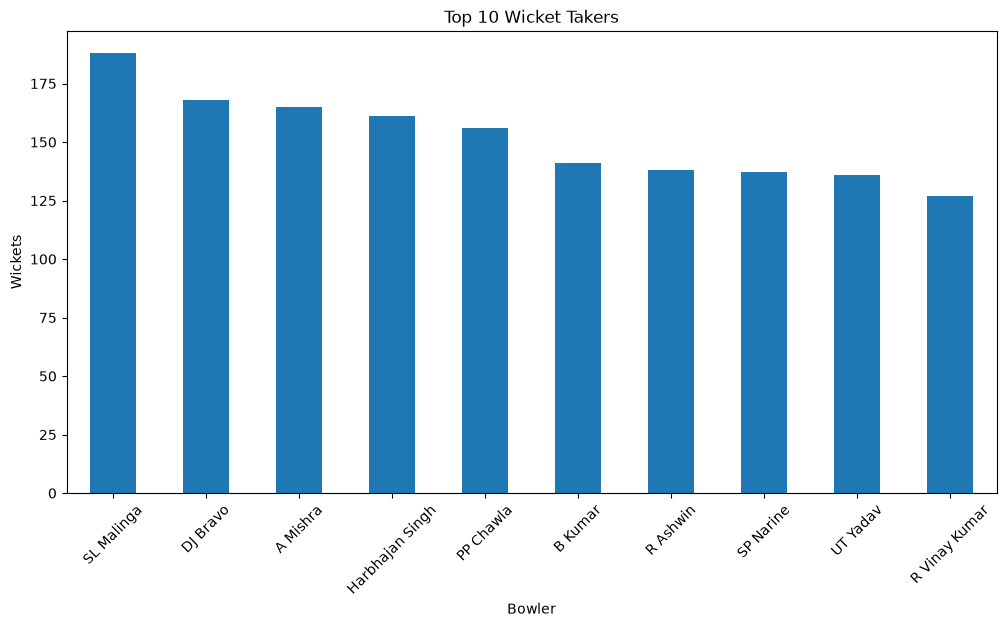

In [72]:
plt.figure(figsize=(12,6))

top_wickets.head(10).plot(kind="bar")

plt.title("Top 10 Wicket Takers")

plt.xlabel("Bowler")

plt.ylabel("Wickets")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- Bowlers with the highest wicket counts consistently break partnerships and influence match outcomes.
- Regular wicket-taking is one of the strongest indicators of bowling effectiveness.

## 4.6 Best Economy Rate

### Business Question

Which bowlers are the most economical?

### Objective

Calculate economy rate for bowlers who have delivered at least 300 balls.

In [73]:
bowler_stats = deliveries.groupby("bowler").agg(
    Balls=("ball", "count"),
    Runs=("total_runs", "sum")
)

bowler_stats = bowler_stats[bowler_stats["Balls"] >= 300]

bowler_stats["Overs"] = bowler_stats["Balls"] / 6

bowler_stats["Economy"] = (
    bowler_stats["Runs"] /
    bowler_stats["Overs"]
)

bowler_stats.sort_values(
    by="Economy"
).head(10)

,Balls,Runs,Overs,Economy
bowler,,,,
A Kumble,983,1089,163.833333,6.646999
DW Steyn,2207,2454,367.833333,6.671500
GD McGrath,329,366,54.833333,6.674772
M Muralitharan,1581,1765,263.500000,6.698292
R Ashwin,3016,3391,502.666667,6.746021
RD Chahar,333,376,55.500000,6.774775
SP Narine,2600,2939,433.333333,6.782308
RE van der Merwe,455,515,75.833333,6.791209
Rashid Khan,1106,1257,184.333333,6.819168


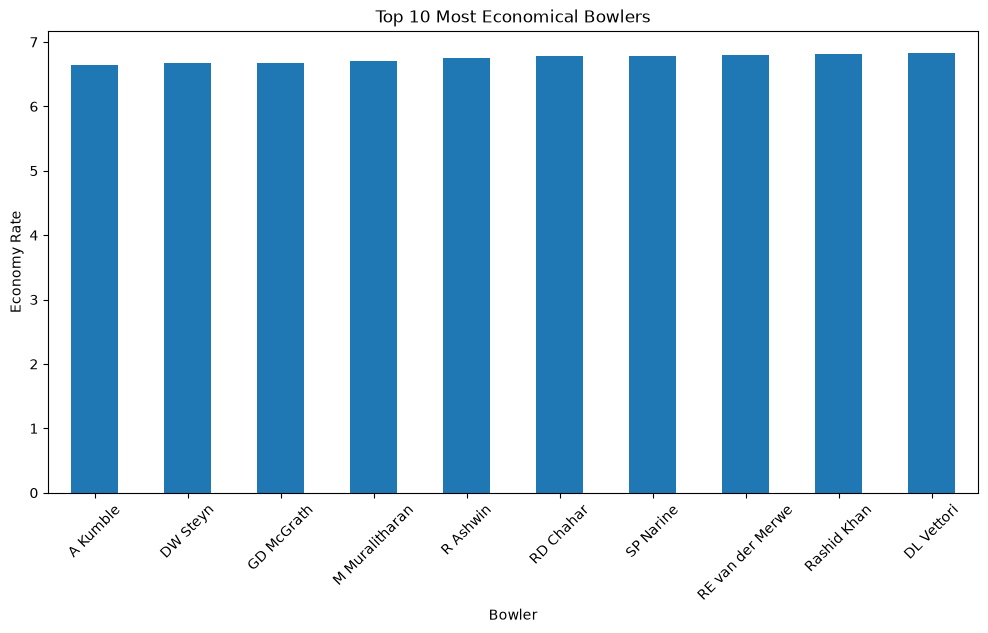

In [74]:
plt.figure(figsize=(12,6))

bowler_stats.sort_values(
    by="Economy"
).head(10)["Economy"].plot(kind="bar")

plt.title("Top 10 Most Economical Bowlers")

plt.xlabel("Bowler")

plt.ylabel("Economy Rate")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- Economy rate measures how effectively a bowler restricts scoring.
- Restricting runs is as valuable as taking wickets, especially in T20 cricket.

# Section 5: Venue Analysis

## 5.1 Top 10 IPL Venues

### Business Question

Which stadiums have hosted the highest number of IPL matches?

### Objective

Identify the most frequently used venues in IPL history.

In [75]:
venue_matches = matches["venue"].value_counts()

venue_matches.head(10)

venue
Eden Gardens                                  77
M Chinnaswamy Stadium                         73
Wankhede Stadium                              73
Feroz Shah Kotla                              67
Rajiv Gandhi International Stadium, Uppal     56
MA Chidambaram Stadium, Chepauk               49
Sawai Mansingh Stadium                        47
Punjab Cricket Association Stadium, Mohali    35
Maharashtra Cricket Association Stadium       21
Dr DY Patil Sports Academy                    17
Name: count, dtype: int64

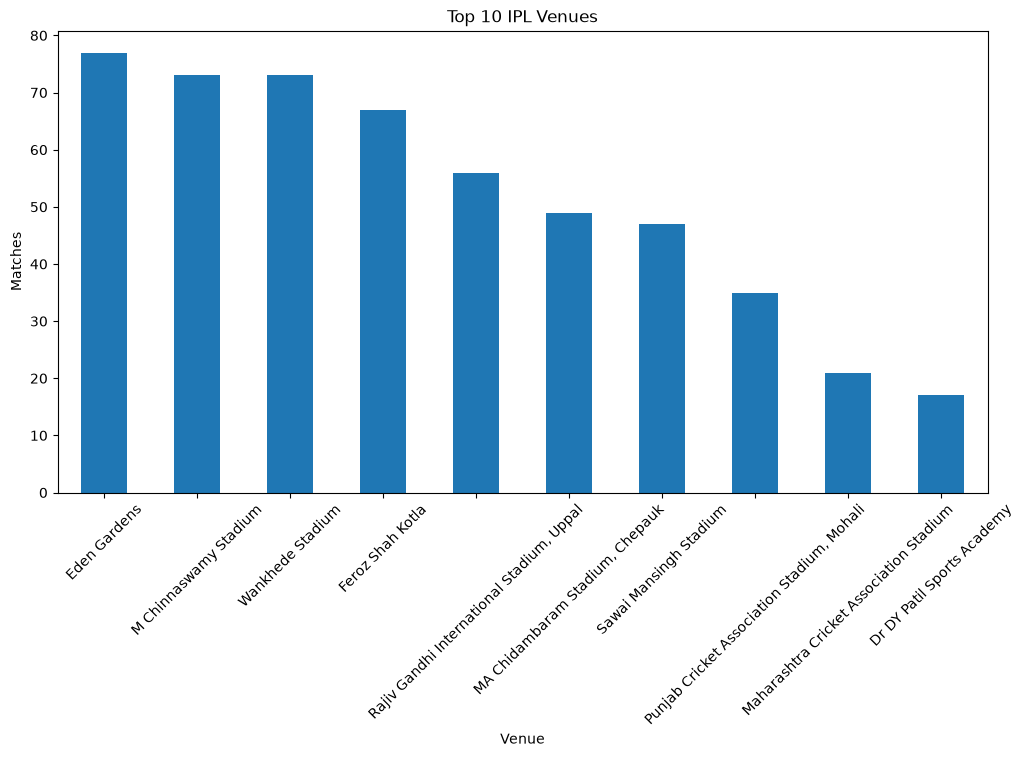

In [76]:
plt.figure(figsize=(12,6))

venue_matches.head(10).plot(kind="bar")

plt.title("Top 10 IPL Venues")

plt.xlabel("Venue")

plt.ylabel("Matches")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- A few venues host a significant share of IPL matches.
- These grounds are often selected for league-stage and playoff matches due to their infrastructure and capacity.

## 5.2 Highest Scoring Venues

### Business Question

Which venues have the highest average first-innings scores?

### Objective

Calculate the average first-innings score at each venue.

In [77]:
first_innings = deliveries[deliveries["inning"] == 1]

match_score = (
    first_innings
    .groupby("match_id")["total_runs"]
    .sum()
    .reset_index()
)

venue_score = match_score.merge(
    matches[["id", "venue"]],
    left_on="match_id",
    right_on="id"
)

avg_score = (
    venue_score
    .groupby("venue")["total_runs"]
    .mean()
    .sort_values(ascending=False)
)

avg_score.head(10)

venue
Brabourne Stadium                                       180.272727
Rajiv Gandhi Intl. Cricket Stadium                      178.625000
IS Bindra Stadium                                       178.285714
Himachal Pradesh Cricket Association Stadium            175.666667
Maharashtra Cricket Association Stadium                 170.952381
M Chinnaswamy Stadium                                   170.575342
Punjab Cricket Association IS Bindra Stadium, Mohali    169.714286
M. Chinnaswamy Stadium                                  169.000000
Saurashtra Cricket Association Stadium                  168.900000
Wankhede Stadium                                        167.876712
Name: total_runs, dtype: float64

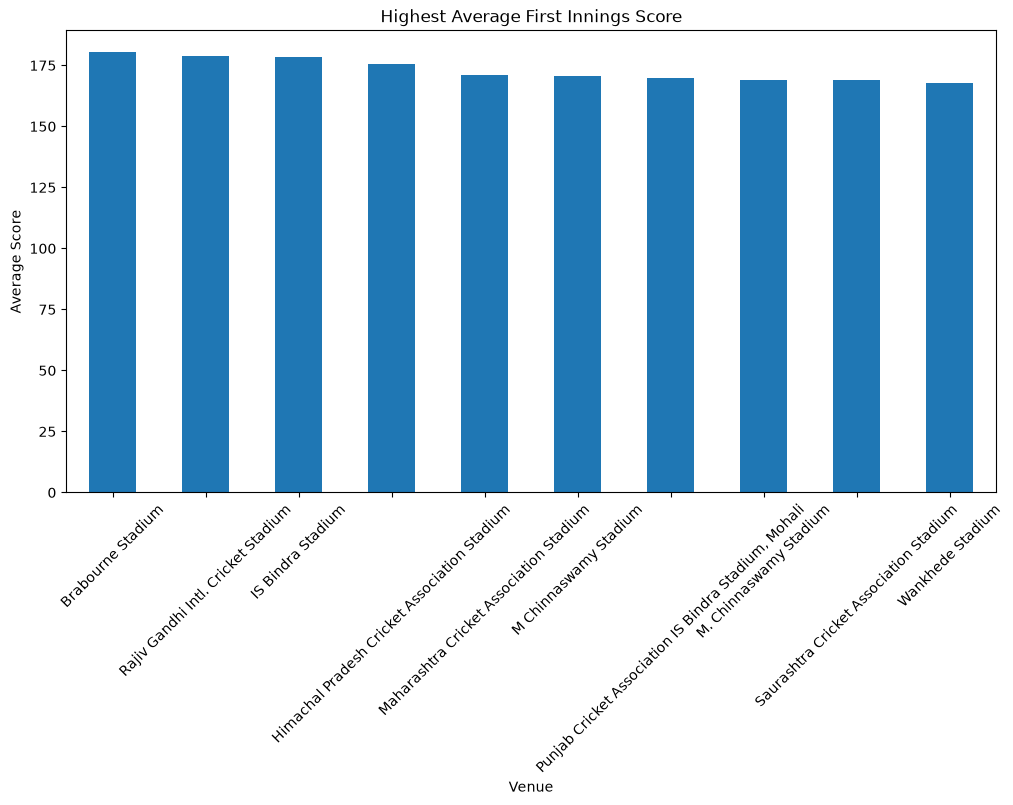

In [78]:
plt.figure(figsize=(12,6))

avg_score.head(10).plot(kind="bar")

plt.title("Highest Average First Innings Score")

plt.xlabel("Venue")

plt.ylabel("Average Score")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- Some venues consistently produce high-scoring matches due to batting-friendly pitches and shorter boundaries.

## 5.3 Lowest Scoring Venues

### Business Question

Which venues have the lowest average first-innings scores?

### Objective

Identify grounds where batting is generally more difficult.

In [79]:
avg_score.sort_values().head(10)

venue
OUTsurance Oval                                     135.000000
Newlands                                            139.428571
New Wanderers Stadium                               144.000000
Shaheed Veer Narayan Singh International Stadium    146.333333
Dr DY Patil Sports Academy                          146.647059
Nehru Stadium                                       146.800000
Buffalo Park                                        147.333333
Sheikh Zayed Stadium                                147.428571
Subrata Roy Sahara Stadium                          147.647059
Dubai International Cricket Stadium                 148.857143
Name: total_runs, dtype: float64

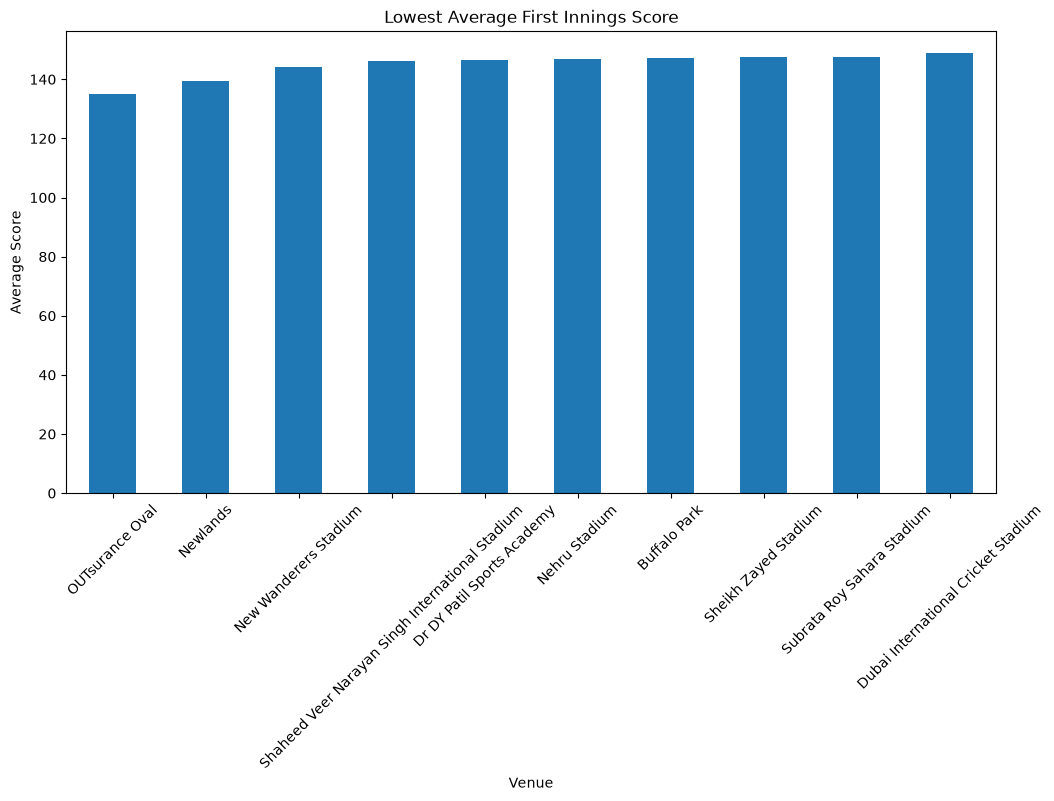

In [80]:
plt.figure(figsize=(12,6))

avg_score.sort_values().head(10).plot(kind="bar")

plt.title("Lowest Average First Innings Score")

plt.xlabel("Venue")

plt.ylabel("Average Score")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- These venues tend to favor bowlers or present more challenging batting conditions.

## 5.4 Average First Innings Score

### Business Question

What is the average first-innings score across all IPL matches?

### Objective

Determine the overall first-innings scoring trend.

In [81]:
average_first = match_score["total_runs"].mean()

print("Average First Innings Score:", round(average_first,2))

Average First Innings Score: 162.37


### Business Insight

- The average first-innings score serves as a benchmark when evaluating batting performances and match conditions.

## 5.5 Best Venues for Chasing

### Business Question

Which venues have the highest number of successful run chases?

### Objective

Identify grounds where chasing teams perform best.

In [82]:
chasing = matches[matches["win_by_wickets"] > 0]

best_chasing = chasing["venue"].value_counts()

best_chasing.head(10)

venue
Eden Gardens                                  45
M Chinnaswamy Stadium                         40
Wankhede Stadium                              37
Feroz Shah Kotla                              33
Rajiv Gandhi International Stadium, Uppal     32
Sawai Mansingh Stadium                        32
Punjab Cricket Association Stadium, Mohali    20
MA Chidambaram Stadium, Chepauk               18
Maharashtra Cricket Association Stadium       14
Dr DY Patil Sports Academy                    10
Name: count, dtype: int64

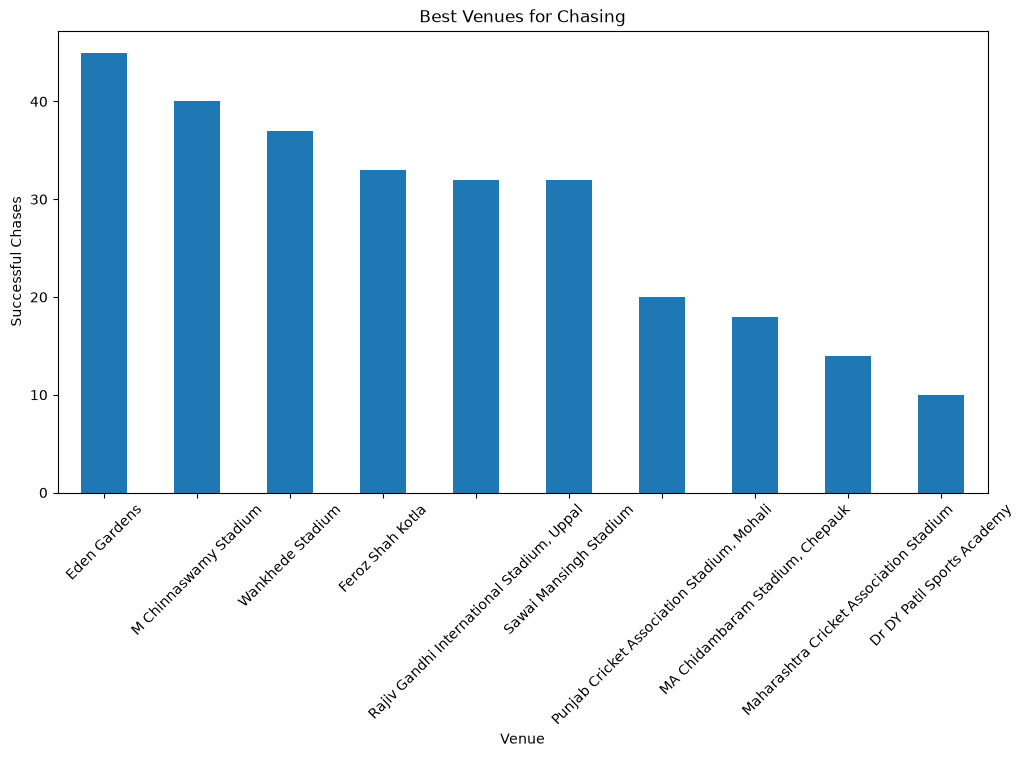

In [83]:
plt.figure(figsize=(12,6))

best_chasing.head(10).plot(kind="bar")

plt.title("Best Venues for Chasing")

plt.xlabel("Venue")

plt.ylabel("Successful Chases")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- These venues have recorded the highest number of successful run chases, suggesting that teams often benefit from batting second under these conditions.

## 5.6 Venues Favoring Batting First

### Business Question

Which venues have the highest number of successful defenses?

### Objective

Identify stadiums where teams batting first have been most successful.

In [84]:
bat_first = matches[matches["win_by_runs"] > 0]

best_batting = bat_first["venue"].value_counts()

best_batting.head(10)

venue
Wankhede Stadium                              35
Feroz Shah Kotla                              33
Eden Gardens                                  32
M Chinnaswamy Stadium                         30
MA Chidambaram Stadium, Chepauk               30
Rajiv Gandhi International Stadium, Uppal     23
Punjab Cricket Association Stadium, Mohali    15
Sawai Mansingh Stadium                        15
Subrata Roy Sahara Stadium                    11
Kingsmead                                      9
Name: count, dtype: int64

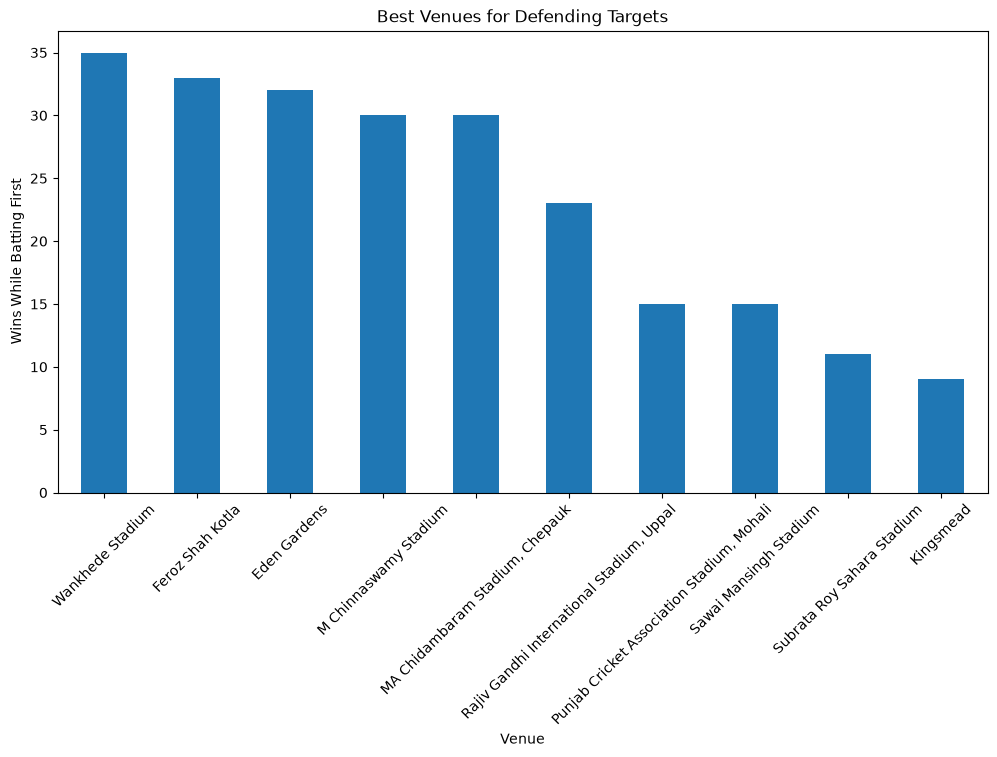

In [85]:
plt.figure(figsize=(12,6))

best_batting.head(10).plot(kind="bar")

plt.title("Best Venues for Defending Targets")

plt.xlabel("Venue")

plt.ylabel("Wins While Batting First")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- These venues show a higher frequency of successful score defenses, indicating that batting first can provide a strategic advantage.

# Section 6: Ball-by-Ball Analysis

## 6.1 Runs Scored in Each Over

### Business Question

Which overs produce the highest number of runs?

### Objective

Analyze scoring patterns across all 20 overs.

In [86]:
runs_per_over = (
    deliveries.groupby("over")["total_runs"]
    .sum()
)

runs_per_over

over
1      9406
2     10961
3     12118
4     12398
5     12426
6     12508
7     10083
8     10737
9     11126
10    10986
11    11387
12    11654
13    11704
14    11982
15    12318
16    12539
17    12935
18    13263
19    12833
20    11905
Name: total_runs, dtype: int64

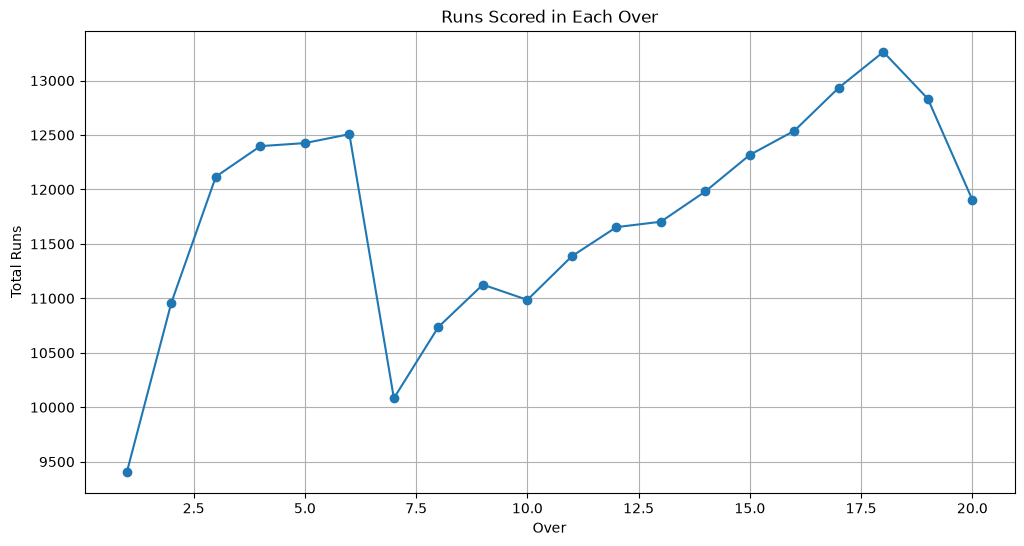

In [87]:
plt.figure(figsize=(12,6))

runs_per_over.plot(
    kind="line",
    marker="o"
)

plt.title("Runs Scored in Each Over")

plt.xlabel("Over")

plt.ylabel("Total Runs")

plt.grid(True)

plt.show()

### Business Insight

- The final overs contribute the highest number of runs.
- Batting teams become more aggressive during the death overs to maximize scoring.

## 6.2 Wickets Taken in Each Over

### Business Question

During which overs do bowlers take the most wickets?

### Objective

Analyze wicket distribution across innings.

In [88]:
wickets = deliveries[
    deliveries["player_dismissed"].notna()
]

wickets_per_over = (
    wickets.groupby("over")
    .size()
)

wickets_per_over

over
1     306
2     350
3     371
4     385
5     385
6     380
7     308
8     324
9     369
10    338
11    383
12    382
13    378
14    434
15    443
16    498
17    534
18    680
19    692
20    894
dtype: int64

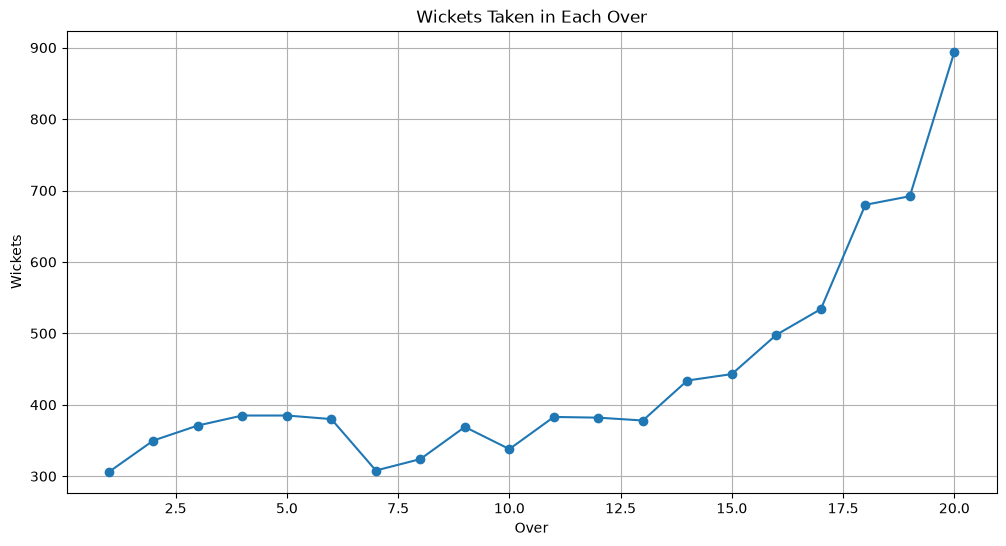

In [89]:
plt.figure(figsize=(12,6))

wickets_per_over.plot(
    kind="line",
    marker="o"
)

plt.title("Wickets Taken in Each Over")

plt.xlabel("Over")

plt.ylabel("Wickets")

plt.grid(True)

plt.show()

### Business Insight

- Wickets generally increase during middle and death overs.
- Increased batting aggression often leads to more dismissals.

## 6.3 Dot Ball Analysis

### Business Question

What percentage of deliveries result in zero runs?

### Objective

Measure bowling effectiveness through dot balls.

In [90]:
dot_balls = deliveries[
    deliveries["total_runs"] == 0
].shape[0]

total_balls = deliveries.shape[0]

dot_percentage = (
    dot_balls / total_balls
) * 100

print("Dot Ball Percentage :", round(dot_percentage,2),"%")

Dot Ball Percentage : 35.18 %


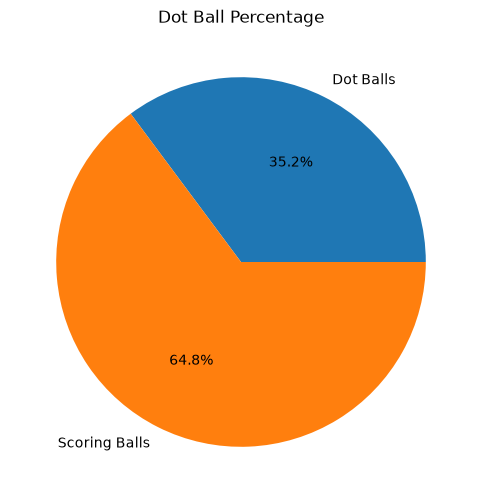

In [91]:
plt.figure(figsize=(6,6))

plt.pie(
    [dot_balls, total_balls-dot_balls],
    labels=["Dot Balls","Scoring Balls"],
    autopct="%1.1f%%"
)

plt.title("Dot Ball Percentage")

plt.show()

### Business Insight

- Dot balls create pressure on the batting side.
- Consistently bowling dot balls is a key strategy in T20 cricket.

## 6.4 Boundary Analysis

### Business Question

What percentage of deliveries result in boundaries?

### Objective

Measure the frequency of fours and sixes.

In [92]:
boundaries = deliveries[
    deliveries["batsman_runs"].isin([4,6])
].shape[0]

boundary_percentage = (
    boundaries / total_balls
) * 100

print("Boundary Percentage :", round(boundary_percentage,2),"%")

Boundary Percentage : 15.95 %


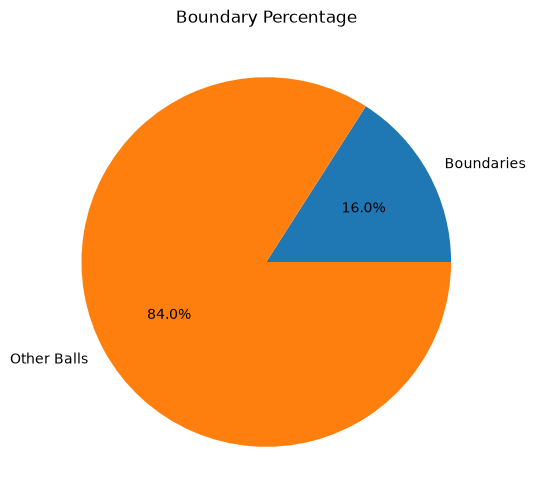

In [93]:
plt.figure(figsize=(6,6))

plt.pie(
    [boundaries,total_balls-boundaries],
    labels=["Boundaries","Other Balls"],
    autopct="%1.1f%%"
)

plt.title("Boundary Percentage")

plt.show()

### Business Insight

- Boundaries account for a significant share of total scoring.
- Teams with higher boundary percentages often achieve stronger batting performances.

## 6.5 Run Distribution

### Business Question

How are runs distributed across deliveries?

### Objective

Analyze the frequency of different scoring outcomes.

In [94]:
run_distribution = (
    deliveries["batsman_runs"]
    .value_counts()
    .sort_index()
)

run_distribution

batsman_runs
0    70836
1    67511
2    11471
3      587
4    20390
5       79
6     8170
7       11
Name: count, dtype: int64

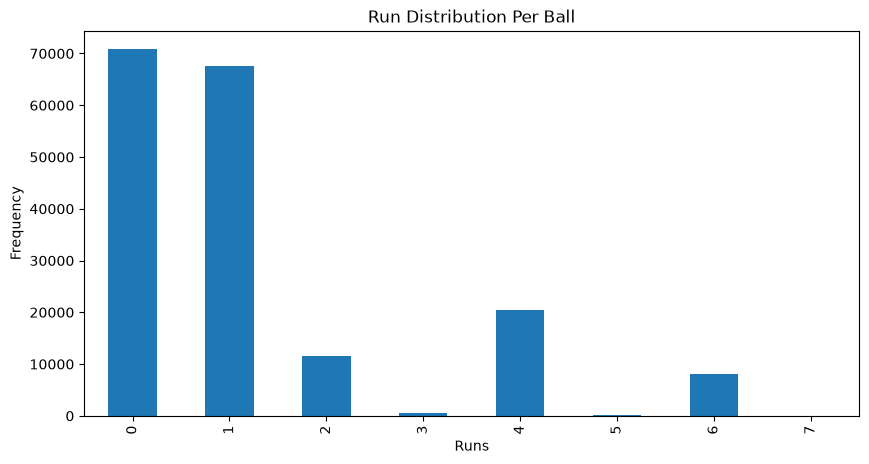

In [95]:
plt.figure(figsize=(10,5))

run_distribution.plot(kind="bar")

plt.title("Run Distribution Per Ball")

plt.xlabel("Runs")

plt.ylabel("Frequency")

plt.show()

### Business Insight

- Singles and dot balls occur most frequently.
- Fours and sixes are less frequent but contribute substantially to total runs.

## 6.6 Extras Analysis

### Business Question

Which type of extras occurs most frequently?

### Objective

Analyze wides, no-balls, byes, and leg byes.

In [96]:
extras = pd.Series({
    "Wide": deliveries["wide_runs"].sum(),
    "No Ball": deliveries["noball_runs"].sum(),
    "Bye": deliveries["bye_runs"].sum(),
    "Leg Bye": deliveries["legbye_runs"].sum()
})

extras

Wide       6576
No Ball     749
Bye         884
Leg Bye    3784
dtype: int64

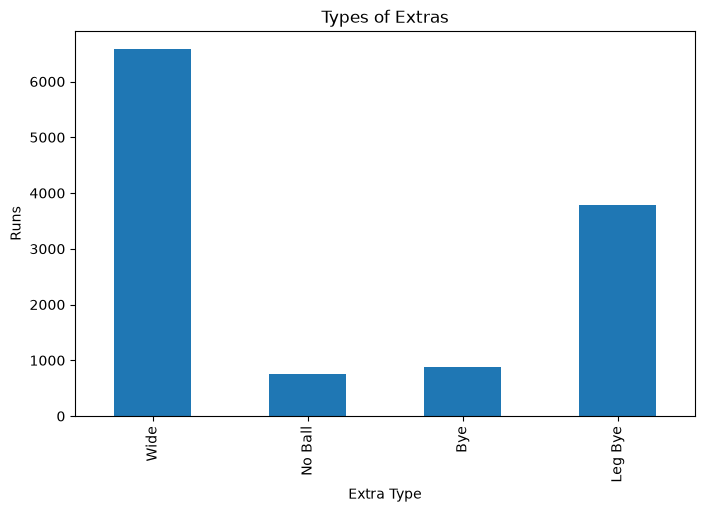

In [97]:
plt.figure(figsize=(8,5))

extras.plot(kind="bar")

plt.title("Types of Extras")

plt.xlabel("Extra Type")

plt.ylabel("Runs")

plt.show()

### Business Insight

- Wide deliveries generally contribute the largest proportion of extras.
- Reducing extras helps teams minimize unnecessary runs conceded.

# Section 7: Season Analysis

## Data Preparation

### Objective

Merge the `matches` and `deliveries` datasets so each ball contains its corresponding IPL season.

In [98]:
season_data = deliveries.merge(
    matches[["id", "season"]],
    left_on="match_id",
    right_on="id",
    how="left"
)

season_data.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder,id,season
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,NaN,NaN,NaN,1,IPL-2017
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,NaN,NaN,NaN,1,IPL-2017
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,4,0,4,NaN,NaN,NaN,1,IPL-2017
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,NaN,NaN,NaN,1,IPL-2017
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,2,2,NaN,NaN,NaN,1,IPL-2017


## 7.1 Total Runs by Season

### Business Question

How many total runs were scored in each IPL season?

### Objective

Analyze how scoring has changed over different IPL seasons.

In [99]:
season_runs = (
    season_data.groupby("season")["total_runs"]
    .sum()
)

season_runs

season
IPL-2008    17937
IPL-2009    16353
IPL-2010    18882
IPL-2011    21154
IPL-2012    22453
IPL-2013    22602
IPL-2014    18931
IPL-2015    18353
IPL-2016    18862
IPL-2017    18786
IPL-2018    20701
IPL-2019    20255
Name: total_runs, dtype: int64

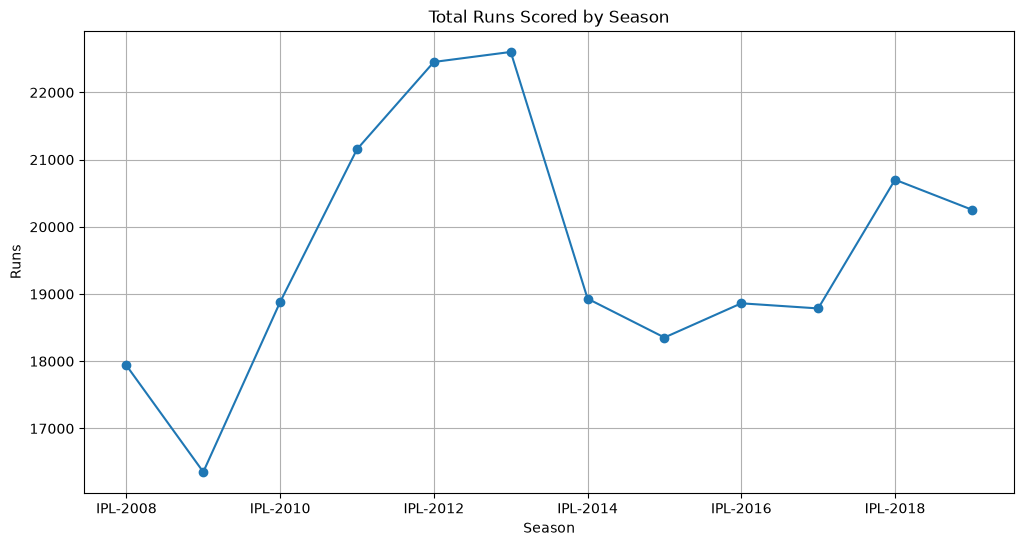

In [100]:
plt.figure(figsize=(12,6))

season_runs.plot(
    kind="line",
    marker="o"
)

plt.title("Total Runs Scored by Season")

plt.xlabel("Season")

plt.ylabel("Runs")

plt.grid(True)

plt.show()

### Business Insight

- Total runs generally increase in seasons with more matches.
- Improvements in batting quality and aggressive T20 strategies have contributed to higher scoring over time.

## 7.2 Wickets by Season

### Business Question

How many wickets fell in each IPL season?

### Objective

Analyze bowling performance across seasons.

In [101]:
season_wickets = (
    season_data[
        season_data["player_dismissed"].notna()
    ]
    .groupby("season")
    .size()
)

season_wickets

season
IPL-2008    690
IPL-2009    698
IPL-2010    725
IPL-2011    813
IPL-2012    858
IPL-2013    912
IPL-2014    674
IPL-2015    691
IPL-2016    666
IPL-2017    711
IPL-2018    719
IPL-2019    677
dtype: int64

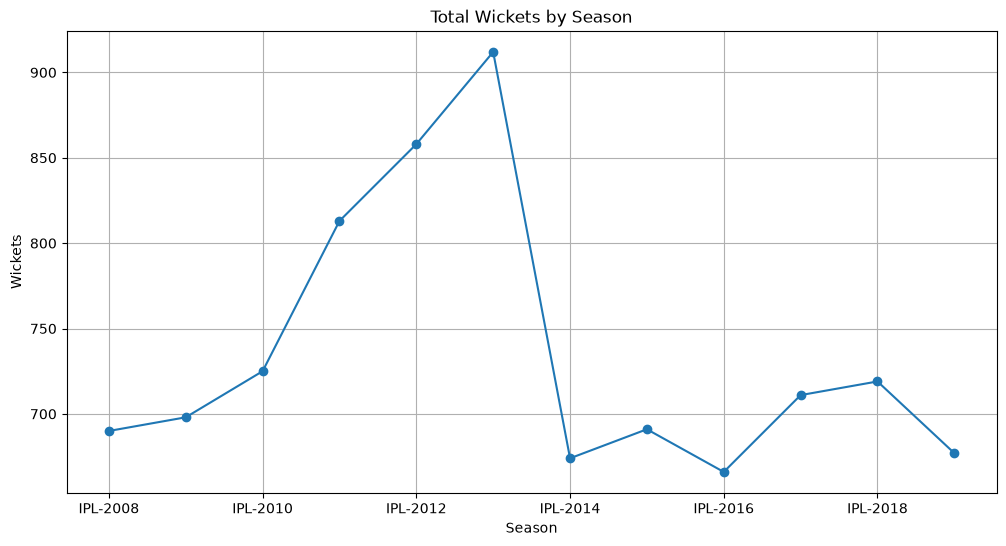

In [102]:
plt.figure(figsize=(12,6))

season_wickets.plot(
    kind="line",
    marker="o"
)

plt.title("Total Wickets by Season")

plt.xlabel("Season")

plt.ylabel("Wickets")

plt.grid(True)

plt.show()

### Business Insight

- Seasons with more matches naturally record more wickets.
- Bowling strategies continue to evolve alongside increasingly aggressive batting.

## 7.3 Average First Innings Score

### Business Question

How has the average first-innings score changed over time?

### Objective

Measure changes in batting performance across seasons.

In [103]:
first_innings = season_data[
    season_data["inning"] == 1
]

match_scores = (
    first_innings
    .groupby(["season", "match_id"])["total_runs"]
    .sum()
    .reset_index()
)

average_score = (
    match_scores
    .groupby("season")["total_runs"]
    .mean()
)

average_score

season
IPL-2008    160.965517
IPL-2009    150.263158
IPL-2010    164.766667
IPL-2011    152.369863
IPL-2012    157.540541
IPL-2013    155.894737
IPL-2014    163.066667
IPL-2015    166.254237
IPL-2016    162.600000
IPL-2017    165.779661
IPL-2018    179.833333
IPL-2019    173.566667
Name: total_runs, dtype: float64

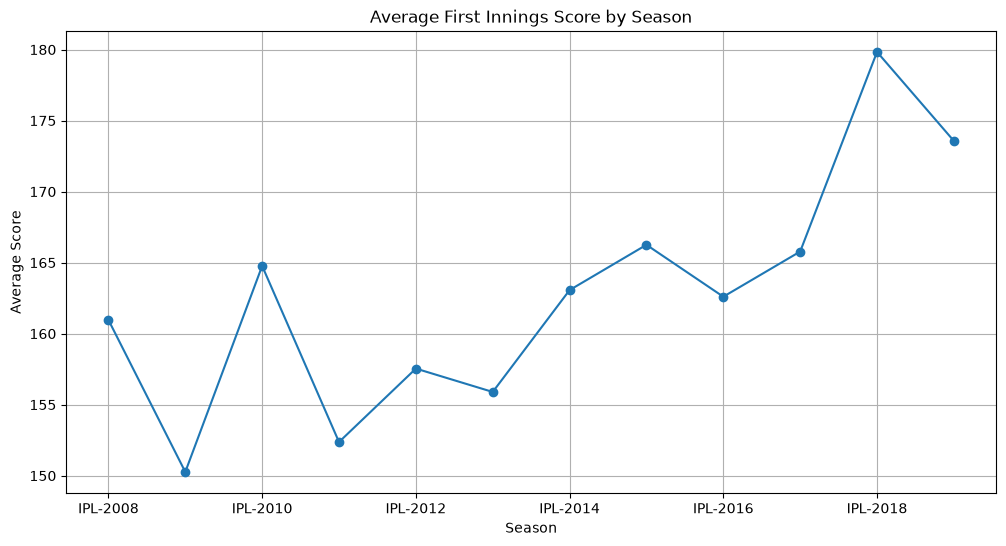

In [104]:
plt.figure(figsize=(12,6))

average_score.plot(
    kind="line",
    marker="o"
)

plt.title("Average First Innings Score by Season")

plt.xlabel("Season")

plt.ylabel("Average Score")

plt.grid(True)

plt.show()

### Business Insight

- Average first-innings scores have generally increased over the years.
- Better batting depth, improved equipment, and evolving T20 tactics have contributed to higher scores.

## 7.4 Matches Played by Season

### Business Question

How many matches were played in each IPL season?

### Objective

Compare tournament size across seasons.

In [105]:
matches_per_season = (
    matches.groupby("season")["id"]
    .count()
)

matches_per_season

season
IPL-2008    58
IPL-2009    57
IPL-2010    60
IPL-2011    73
IPL-2012    74
IPL-2013    76
IPL-2014    60
IPL-2015    59
IPL-2016    60
IPL-2017    59
IPL-2018    60
IPL-2019    60
Name: id, dtype: int64

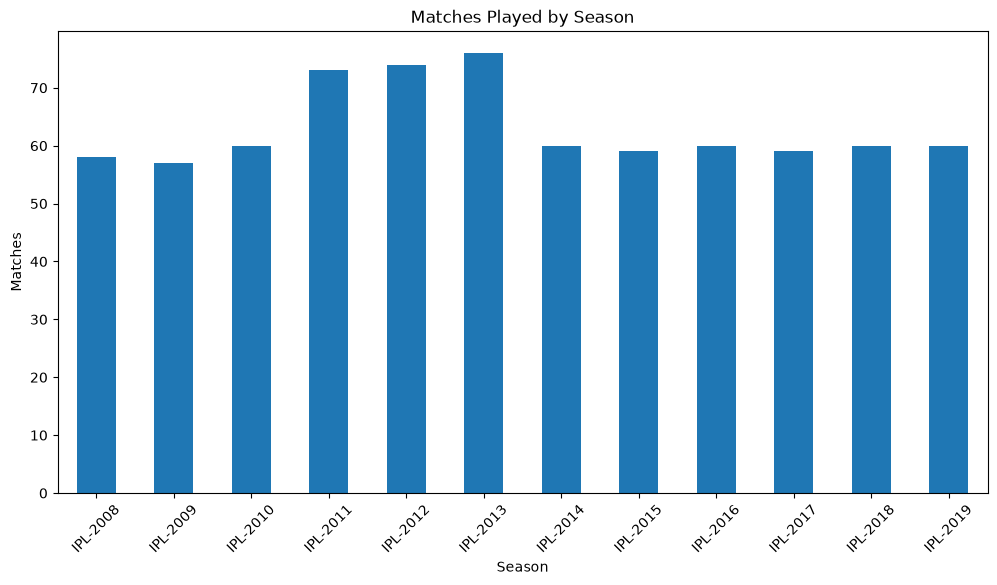

In [106]:
plt.figure(figsize=(12,6))

matches_per_season.plot(
    kind="bar"
)

plt.title("Matches Played by Season")

plt.xlabel("Season")

plt.ylabel("Matches")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- The number of matches has changed due to expansion teams and tournament format revisions.

## 7.5 IPL Champions by Season

### Business Question

Which team won each IPL season?

### Objective

Identify the IPL champion for every season.

In [107]:
champions = (
    matches
    .sort_values("date")
    .groupby("season")
    .last()[["winner"]]
)

champions

,winner
season,
IPL-2008,Rajasthan Royals
IPL-2009,Deccan Chargers
IPL-2010,Chennai Super Kings
IPL-2011,Chennai Super Kings
IPL-2012,Kolkata Knight Riders
IPL-2013,Mumbai Indians
IPL-2014,Kolkata Knight Riders
IPL-2015,Mumbai Indians
IPL-2016,Sunrisers Hyderabad


### Business Insight

- The list of champions highlights the franchises that have consistently succeeded across different IPL seasons.
- Comparing champions over time helps identify periods of dominance by particular teams.

## 7.6 Team Wins by Season

### Business Question

How many matches did each team win in every IPL season?

### Objective

Compare team performance across seasons.

In [108]:
team_season_wins = (
    matches
    .groupby(["season", "winner"])
    .size()
    .unstack(fill_value=0)
)

team_season_wins

winner,Chennai Super Kings,Deccan Chargers,Delhi Capitals,Gujarat Lions,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Mumbai Indians,No Result,Pune Warriors,Rajasthan Royals,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
season,,,,,,,,,,,,,,
IPL-2008,9,2,7,0,10,0,6,7,0,0,13,0,4,0
IPL-2009,8,9,10,0,7,0,3,5,0,0,6,0,9,0
IPL-2010,9,8,7,0,4,0,7,11,0,0,6,0,8,0
IPL-2011,11,6,4,0,7,6,8,10,1,4,6,0,10,0
IPL-2012,10,4,11,0,8,0,12,10,0,4,7,0,8,0
IPL-2013,12,0,3,0,8,0,6,13,0,4,11,0,9,10
IPL-2014,10,0,2,0,12,0,11,7,0,0,7,0,5,6
IPL-2015,10,0,5,0,3,0,7,10,2,0,7,0,8,7
IPL-2016,0,0,7,9,4,0,8,7,0,0,0,5,9,11


<Figure size 1400x700 with 0 Axes>

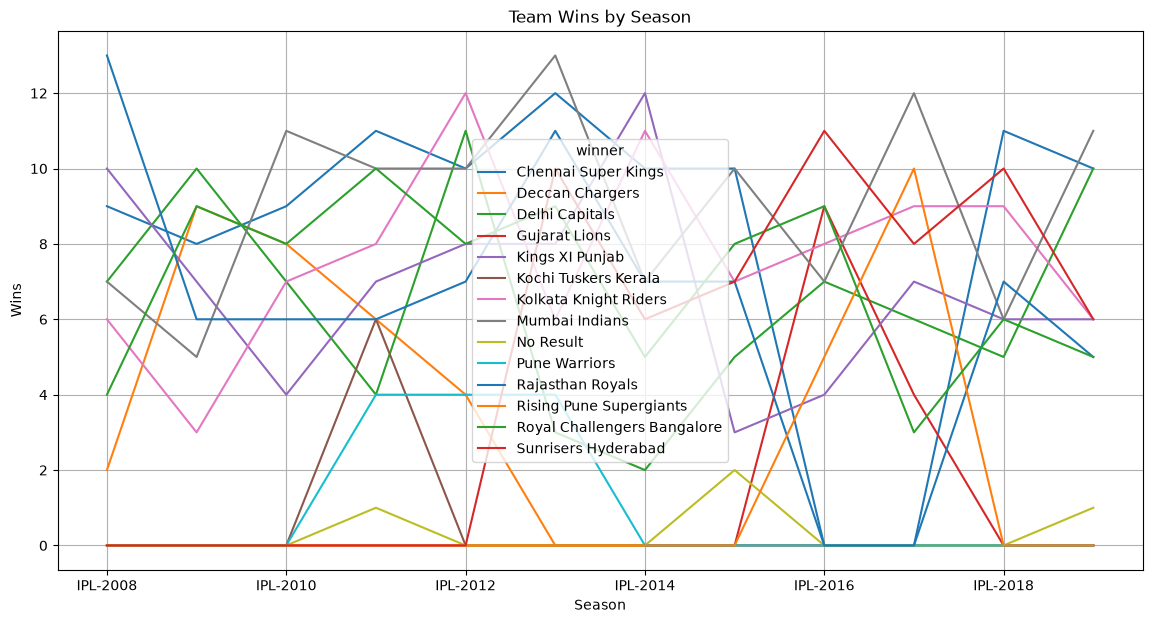

In [109]:
plt.figure(figsize=(14,7))

team_season_wins.plot(figsize=(14,7))

plt.title("Team Wins by Season")

plt.xlabel("Season")

plt.ylabel("Wins")

plt.grid(True)

plt.show()

### Business Insight

- Team performance varies across seasons due to player transfers, coaching strategies, and squad composition.
- This analysis highlights periods of sustained success and rebuilding phases for franchises.